In [2]:
import pandas as pd
from pathlib import Path

# Define output directory for all results
output_base_dir = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus')
output_base_dir.mkdir(parents=True, exist_ok=True)

# Load tallo.csv
data_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\tallo.csv')
df_tallo = pd.read_csv(data_path)

print(f'✓ Loaded: {data_path}')
print(f'✓ Output directory: {output_base_dir}')
print(f'\nShape: {df_tallo.shape}')
print(f'\nColumns: {list(df_tallo.columns)}')
print(f'\nFirst 5 rows:')
print(df_tallo.head())
print(f'\nData types:')
print(df_tallo.dtypes)
print(f'\nBasic statistics:')
print(df_tallo.describe())

✓ Loaded: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\tallo.csv
✓ Output directory: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus

Shape: (498838, 13)

Columns: ['tree_id', 'division', 'family', 'genus', 'species', 'latitude', 'longitude', 'stem_diameter_cm', 'height_m', 'crown_radius_m', 'height_outlier', 'crown_radius_outlier', 'reference_id']

First 5 rows:
  tree_id    division      family   genus           species  latitude  \
0     T_1  Angiosperm  Betulaceae  Betula  Betula pubescens    67.395   
1     T_2  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
2     T_3  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
3     T_4  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
4     T_5  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   

   longitude  stem_diameter_cm  height_m  crown_radius_m height_outlier  \
0     28.723              1

In [3]:
# Extract genus from species name and filter by genus
# First, extract genus (first word of species name)
df_tallo['genus'] = df_tallo['species'].str.split().str[0]

genus_to_keep = [
    'Fagus',
    'Alnus',
    'Fraxinus',
    'Populus',
    'Pinus',
    'Larix',
    'Abies',
    'Picea'
]

print(f'Original shape: {df_tallo.shape}')
print(f'\nGenus in dataset:')
print(df_tallo['genus'].value_counts())

# Filter to keep only the specified genera
df_tallo = df_tallo[df_tallo['genus'].isin(genus_to_keep)]

# Remove samples with diameter < 10 cm
df_tallo = df_tallo[df_tallo['stem_diameter_cm'] >= 10]

print(f'\n✓ Filtered to keep only specified genera and D >= 10 cm')
print(f'New shape: {df_tallo.shape}')
print(f'\nRemaining genera:')
print(df_tallo['genus'].value_counts())
print(f'\nSpecies per genus:')
for genus in sorted(df_tallo['genus'].unique()):
    species_list = df_tallo[df_tallo['genus'] == genus]['species'].unique()
    print(f'  {genus}: {", ".join(species_list)}')
print(f'\nFirst 5 rows:')
print(df_tallo.head())

Original shape: (498838, 13)

Genus in dataset:
genus
Quercus          69107
Pinus            66706
Eucalyptus       22989
Picea            13837
Fagus            13009
                 ...  
Tetraberlinia        1
Oxystigma            1
Detarium             1
Bikinia              1
Cocculus             1
Name: count, Length: 1452, dtype: int64

✓ Filtered to keep only specified genera and D >= 10 cm
New shape: (93376, 13)

Remaining genera:
genus
Pinus       60271
Picea       11365
Fagus       10349
Abies        5278
Fraxinus     2541
Populus      2215
Larix        1159
Alnus         198
Name: count, dtype: int64

Species per genus:
  Abies: Abies balsamea, Abies alba, Abies veitchii, Abies lasiocarpa, Abies firma, Abies sachalinensis, Abies grandis, Abies pindrow, Abies pinsapo, Abies sibirica, Abies nephrolepis, Abies holophylla, Abies concolor, Abies amabilis, Abies procera, Abies magnifica
  Alnus: Alnus incana, Alnus glutinosa, Alnus alnobetula, Alnus hirsuta, Alnus subcordata, A

In [4]:
# Export filtered dataset
output_path = output_base_dir / 'tallofiltered_genus.csv'
df_tallo.to_csv(output_path, index=False)

print(f'✓ Exported to: {output_path}')
print(f'\nFile details:')
print(f'  - Rows: {len(df_tallo):,}')
print(f'  - Columns: {len(df_tallo.columns)}')
print(f'  - Species: {df_tallo["species"].nunique()}')
print(f'\nFile size: {output_path.stat().st_size / 1024 / 1024:.2f} MB')

✓ Exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus\tallofiltered_genus.csv

File details:
  - Rows: 93,376
  - Columns: 13
  - Species: 114

File size: 7.59 MB


In [5]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Define allometric model: D = a * H^b
def allometric_model(H, a, b):
    return a * H**b

# Dictionary to store results
allometry_results = {}

print('='*80)
print('D-H ALLOMETRIC RELATIONSHIPS BY GENUS')
print('='*80)

genus_list = sorted(df_tallo['genus'].unique())

for genus in genus_list:
    genus_data = df_tallo[df_tallo['genus'] == genus].copy()
    
    # Remove NaN values
    genus_data = genus_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    if len(genus_data) < 10:  # Skip if not enough data
        continue
    
    H = genus_data['height_m'].values
    D = genus_data['stem_diameter_cm'].values
    
    # Fit model using curve_fit
    try:
        popt, pcov = curve_fit(allometric_model, H, D, p0=[1, 0.5], maxfev=5000)
        a, b = popt
        
        # Calculate R-squared using log-linear regression
        H_log = np.log(H)
        D_log = np.log(D)
        slope, intercept, r_value, p_value, std_err = linregress(H_log, D_log)
        r_squared = r_value**2
        
        # Store results
        allometry_results[genus] = {
            'a': a,
            'b': b,
            'r_squared': r_squared,
            'n_samples': len(genus_data),
            'H_min': H.min(),
            'H_max': H.max(),
            'D_min': D.min(),
            'D_max': D.max()
        }
        
        print(f'\n{genus}')
        print(f'  Model: D = {a:.4f} × H^{b:.4f}')
        print(f'  R² = {r_squared:.4f}')
        print(f'  N = {len(genus_data):,}')
        print(f'  H range: {H.min():.2f} - {H.max():.2f} m')
        print(f'  D range: {D.min():.2f} - {D.max():.2f} cm')
    
    except Exception as e:
        print(f'\n{genus}: Error in fitting - {str(e)}')

print('\n' + '='*80)

D-H ALLOMETRIC RELATIONSHIPS BY GENUS

Abies
  Model: D = 1.4200 × H^1.0212
  R² = 0.6340
  N = 5,272
  H range: 1.40 - 53.90 m
  D range: 10.00 - 118.00 cm

Alnus
  Model: D = 1.6345 × H^0.9509
  R² = 0.5031
  N = 197
  H range: 3.50 - 40.00 m
  D range: 10.00 - 81.00 cm

Fagus
  Model: D = 1.5779 × H^0.9864
  R² = 0.3434
  N = 10,018
  H range: 1.50 - 55.30 m
  D range: 10.00 - 162.00 cm

Fraxinus
  Model: D = 4.8060 × H^0.5687
  R² = 0.3047
  N = 2,536
  H range: 1.50 - 47.80 m
  D range: 10.00 - 112.40 cm

Larix
  Model: D = 0.6493 × H^1.2501
  R² = 0.6694
  N = 1,155
  H range: 3.90 - 44.00 m
  D range: 10.00 - 82.00 cm

Picea
  Model: D = 1.2346 × H^1.0411
  R² = 0.6904
  N = 11,349
  H range: 1.70 - 96.00 m
  D range: 10.00 - 305.00 cm

Pinus
  Model: D = 7.0973 × H^0.5325
  R² = 0.3527
  N = 60,029
  H range: 1.50 - 61.20 m
  D range: 10.00 - 132.00 cm

Populus
  Model: D = 2.0986 × H^0.8493
  R² = 0.3746
  N = 2,212
  H range: 2.30 - 39.60 m
  D range: 10.00 - 103.50 cm



✓ Figure saved: DH_Curves_by_Genus.png


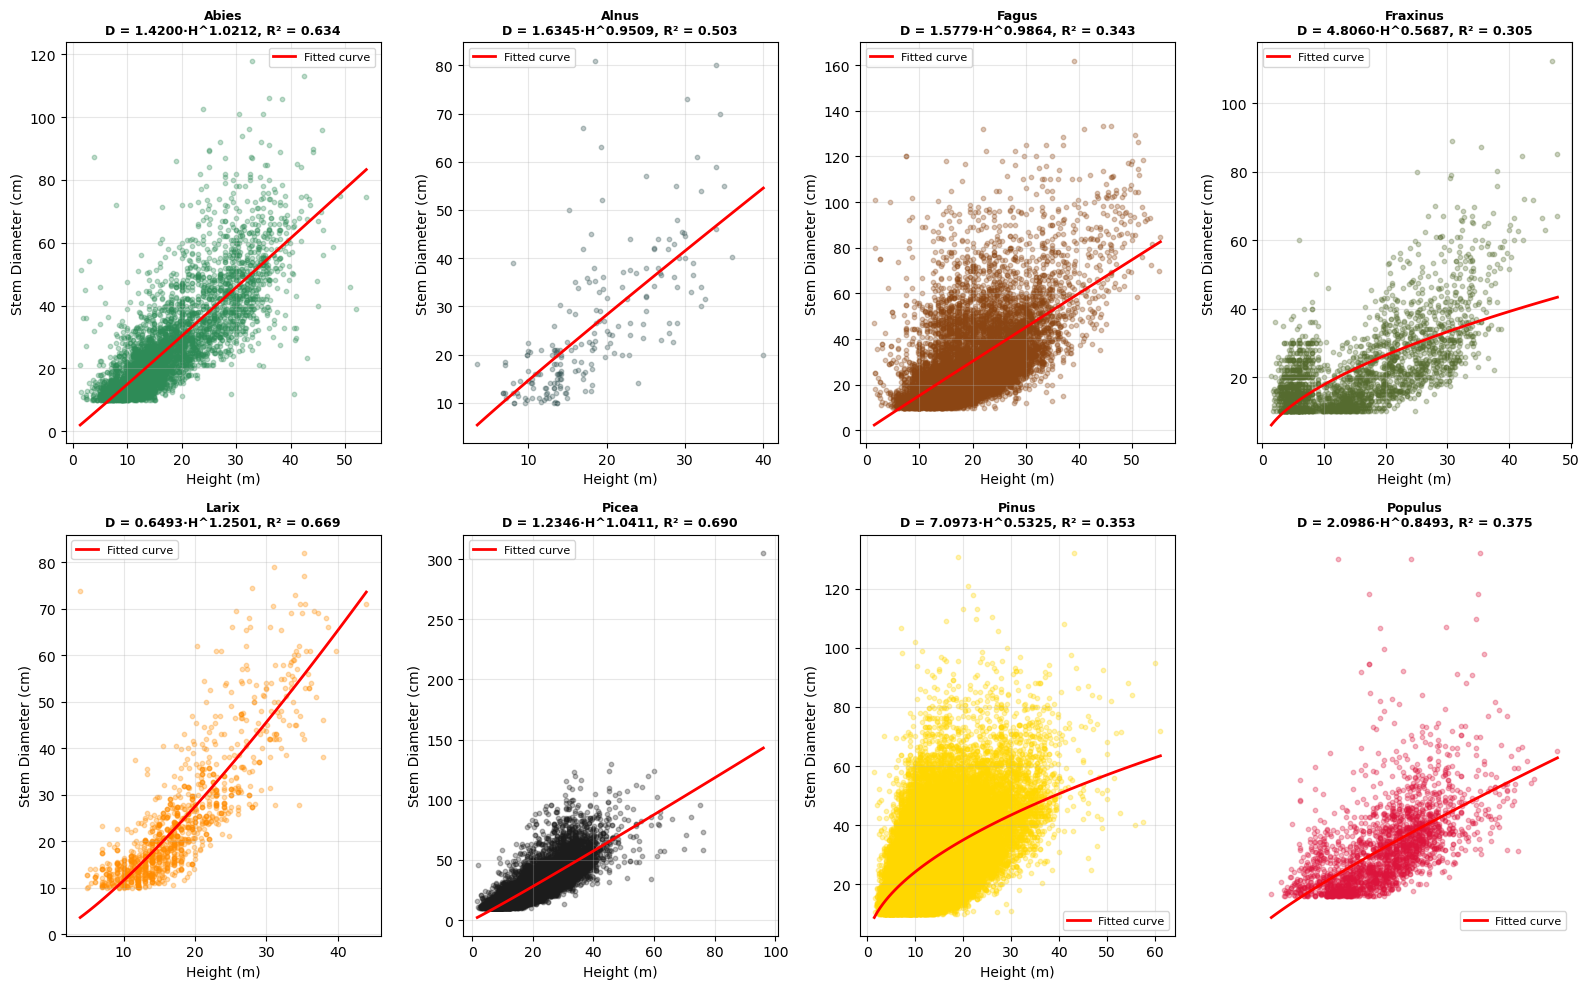

In [6]:
# Create visualization of D-H curves
colors = {
    'Fagus': '#8B4513',        # Brown
    'Alnus': '#2F4F4F',        # Dark slate gray
    'Fraxinus': '#556B2F',     # Dark olive green
    'Populus': '#DC143C',      # Crimson
    'Pinus': '#FFD700',        # Gold
    'Larix': '#FF8C00',        # Dark orange
    'Abies': '#2E8B57',        # Forest green
    'Picea': '#1C1C1C'         # Dark charcoal
}

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, genus in enumerate(sorted(allometry_results.keys())):
    ax = axes[idx]
    
    genus_data = df_tallo[df_tallo['genus'] == genus].dropna(subset=['stem_diameter_cm', 'height_m'])
    H = genus_data['height_m'].values
    D = genus_data['stem_diameter_cm'].values
    
    result = allometry_results[genus]
    a, b = result['a'], result['b']
    r_sq = result['r_squared']
    
    # Plot raw data
    ax.scatter(H, D, alpha=0.3, s=10, color=colors.get(genus, 'gray'))
    
    # Plot fitted curve
    H_range = np.linspace(H.min(), H.max(), 100)
    D_fitted = allometric_model(H_range, a, b)
    ax.plot(H_range, D_fitted, 'r-', linewidth=2, label=f'Fitted curve')
    
    # Formatting
    ax.set_xlabel('Height (m)', fontsize=10)
    ax.set_ylabel('Stem Diameter (cm)', fontsize=10)
    ax.set_title(f'{genus}\nD = {a:.4f}·H^{b:.4f}, R² = {r_sq:.3f}', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
fig_path = output_base_dir / 'DH_Curves_by_Genus.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print('✓ Figure saved: DH_Curves_by_Genus.png')
plt.show()

In [7]:
# Create summary table
import pandas as pd

summary_data = []
for genus, result in sorted(allometry_results.items()):
    summary_data.append({
        'Genus': genus,
        'Formula': f"D = {result['a']:.4f} × H^{result['b']:.4f}",
        'a': result['a'],
        'b': result['b'],
        'R²': result['r_squared'],
        'N samples': result['n_samples'],
        'H min (m)': result['H_min'],
        'H max (m)': result['H_max'],
        'D min (cm)': result['D_min'],
        'D max (cm)': result['D_max']
    })

summary_df = pd.DataFrame(summary_data)

print('\n' + '='*80)
print('ALLOMETRIC MODEL SUMMARY TABLE')
print('='*80)
print(summary_df.to_string(index=False))

# Export summary to CSV
output_csv = output_base_dir / 'AllometricModels_DH_Genus.csv'
summary_df.to_csv(output_csv, index=False)
print(f'\n✓ Summary exported to: {output_csv.name}')


ALLOMETRIC MODEL SUMMARY TABLE
   Genus               Formula        a        b       R²  N samples  H min (m)  H max (m)  D min (cm)  D max (cm)
   Abies D = 1.4200 × H^1.0212 1.419974 1.021231 0.633955       5272        1.4       53.9        10.0       118.0
   Alnus D = 1.6345 × H^0.9509 1.634544 0.950889 0.503114        197        3.5       40.0        10.0        81.0
   Fagus D = 1.5779 × H^0.9864 1.577872 0.986368 0.343359      10018        1.5       55.3        10.0       162.0
Fraxinus D = 4.8060 × H^0.5687 4.805979 0.568721 0.304719       2536        1.5       47.8        10.0       112.4
   Larix D = 0.6493 × H^1.2501 0.649330 1.250083 0.669358       1155        3.9       44.0        10.0        82.0
   Picea D = 1.2346 × H^1.0411 1.234599 1.041137 0.690381      11349        1.7       96.0        10.0       305.0
   Pinus D = 7.0973 × H^0.5325 7.097335 0.532476 0.352724      60029        1.5       61.2        10.0       132.0
 Populus D = 2.0986 × H^0.8493 2.098569 0.849274

In [8]:
# Geographic filtering by latitude and longitude
print('\n' + '='*80)
print('GEOGRAPHIC FILTERING')
print('='*80)

# Define geographic bounds (around Genissiat, France)
lat_min = 41.70
lat_max = 50.70
lon_min = -0.33
lon_max = 12.61

print(f'\nTarget region (Genissiat, France):')
print(f'  Latitude: {lat_min}° to {lat_max}° (reference: 46.2044° ±4.50°)')
print(f'  Longitude: {lon_min}° to {lon_max}° (reference: 6.1432° ±6.47°)')

print(f'\nBefore filtering:')
print(f'  Total records: {len(df_tallo):,}')
print(f'  Lat range: {df_tallo["latitude"].min():.2f}° to {df_tallo["latitude"].max():.2f}°')
print(f'  Lon range: {df_tallo["longitude"].min():.2f}° to {df_tallo["longitude"].max():.2f}°')

# Apply geographic filter
df_tallo_geo = df_tallo[
    (df_tallo['latitude'] >= lat_min) &
    (df_tallo['latitude'] <= lat_max) &
    (df_tallo['longitude'] >= lon_min) &
    (df_tallo['longitude'] <= lon_max)
].copy()

print(f'\nAfter filtering:')
print(f'  Remaining records: {len(df_tallo_geo):,}')
print(f'  Percentage retained: {100*len(df_tallo_geo)/len(df_tallo):.1f}%')
print(f'  Lat range: {df_tallo_geo["latitude"].min():.2f}° to {df_tallo_geo["latitude"].max():.2f}°')
print(f'  Lon range: {df_tallo_geo["longitude"].min():.2f}° to {df_tallo_geo["longitude"].max():.2f}°')

print(f'\nGenus distribution after geographic filtering:')
print(df_tallo_geo['genus'].value_counts().sort_index())

# Update df_tallo with geographic subset
df_tallo = df_tallo_geo.copy()
print(f'\n✓ df_tallo updated with geographic subset')


GEOGRAPHIC FILTERING

Target region (Genissiat, France):
  Latitude: 41.7° to 50.7° (reference: 46.2044° ±4.50°)
  Longitude: -0.33° to 12.61° (reference: 6.1432° ±6.47°)

Before filtering:
  Total records: 93,376
  Lat range: -34.15° to 69.88°
  Lon range: -149.29° to 148.00°

After filtering:
  Remaining records: 13,944
  Percentage retained: 14.9%
  Lat range: 41.70° to 50.55°
  Lon range: -0.33° to 12.00°

Genus distribution after geographic filtering:
genus
Abies        450
Alnus         50
Fagus       2769
Fraxinus     598
Larix        226
Picea       2865
Pinus       6874
Populus      112
Name: count, dtype: int64

✓ df_tallo updated with geographic subset


In [9]:
# Export geographically filtered dataset
output_geo_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\tallofiltered_geographic.csv')
output_geo_path.parent.mkdir(parents=True, exist_ok=True)
df_tallo.to_csv(output_geo_path, index=False)

print(f'\n✓ Geographic filtered dataset exported: {output_geo_path.name}')
print(f'  Records: {len(df_tallo):,}')
print(f'  Columns: {len(df_tallo.columns)}')
print(f'  File size: {output_geo_path.stat().st_size / 1024 / 1024:.2f} MB')


✓ Geographic filtered dataset exported: tallofiltered_geographic.csv
  Records: 13,944
  Columns: 13
  File size: 1.12 MB


In [10]:
# Fit allometric D-H models for GEOGRAPHIC SUBSET
allometry_results_geo = {}

print('\n' + '='*80)
print('D-H ALLOMETRIC RELATIONSHIPS BY GENUS (GEOGRAPHIC SUBSET - GENISSIAT REGION)')
print('='*80)

genus_list_geo = sorted(df_tallo['genus'].unique())

for genus in genus_list_geo:
    genus_data = df_tallo[df_tallo['genus'] == genus].copy()
    
    # Remove NaN values
    genus_data = genus_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    if len(genus_data) < 10:  # Skip if not enough data
        continue
    
    H = genus_data['height_m'].values
    D = genus_data['stem_diameter_cm'].values
    
    # Fit model using curve_fit
    try:
        popt, pcov = curve_fit(allometric_model, H, D, p0=[1, 0.5], maxfev=5000)
        a, b = popt
        
        # Calculate R-squared using log-linear regression
        H_log = np.log(H)
        D_log = np.log(D)
        slope, intercept, r_value, p_value, std_err = linregress(H_log, D_log)
        r_squared = r_value**2
        
        # Store results
        allometry_results_geo[genus] = {
            'a': a,
            'b': b,
            'r_squared': r_squared,
            'n_samples': len(genus_data),
            'H_min': H.min(),
            'H_max': H.max(),
            'D_min': D.min(),
            'D_max': D.max()
        }
        
        print(f'\n{genus}')
        print(f'  Model: D = {a:.4f} × H^{b:.4f}')
        print(f'  R² = {r_squared:.4f}')
        print(f'  N = {len(genus_data):,}')
        print(f'  H range: {H.min():.2f} - {H.max():.2f} m')
        print(f'  D range: {D.min():.2f} - {D.max():.2f} cm')
    
    except Exception as e:
        print(f'\n{genus}: Error in fitting - {str(e)}')

print('\n' + '='*80)


D-H ALLOMETRIC RELATIONSHIPS BY GENUS (GEOGRAPHIC SUBSET - GENISSIAT REGION)

Abies
  Model: D = 1.9197 × H^0.9415
  R² = 0.6520
  N = 450
  H range: 4.50 - 45.80 m
  D range: 10.00 - 113.00 cm

Alnus
  Model: D = 1.0014 × H^1.0726
  R² = 0.2610
  N = 50
  H range: 6.80 - 26.00 m
  D range: 10.00 - 35.20 cm

Fagus
  Model: D = 1.7596 × H^0.9036
  R² = 0.3198
  N = 2,544
  H range: 2.10 - 43.90 m
  D range: 10.00 - 118.10 cm

Fraxinus
  Model: D = 0.4454 × H^1.2816
  R² = 0.4936
  N = 595
  H range: 1.50 - 45.80 m
  D range: 10.00 - 87.10 cm

Larix
  Model: D = 2.2567 × H^0.9143
  R² = 0.7515
  N = 222
  H range: 4.90 - 44.00 m
  D range: 10.00 - 82.00 cm

Picea
  Model: D = 0.7539 × H^1.1851
  R² = 0.7604
  N = 2,855
  H range: 3.00 - 48.60 m
  D range: 10.00 - 109.00 cm

Pinus
  Model: D = 6.6268 × H^0.5443
  R² = 0.3734
  N = 6,706
  H range: 2.30 - 37.90 m
  D range: 10.00 - 101.90 cm

Populus
  Model: D = 5.3654 × H^0.5585
  R² = 0.3271
  N = 112
  H range: 6.00 - 36.20 m
  D rang

✓ Figure saved: DH_Curves_Geographic_Subset_Genus.png


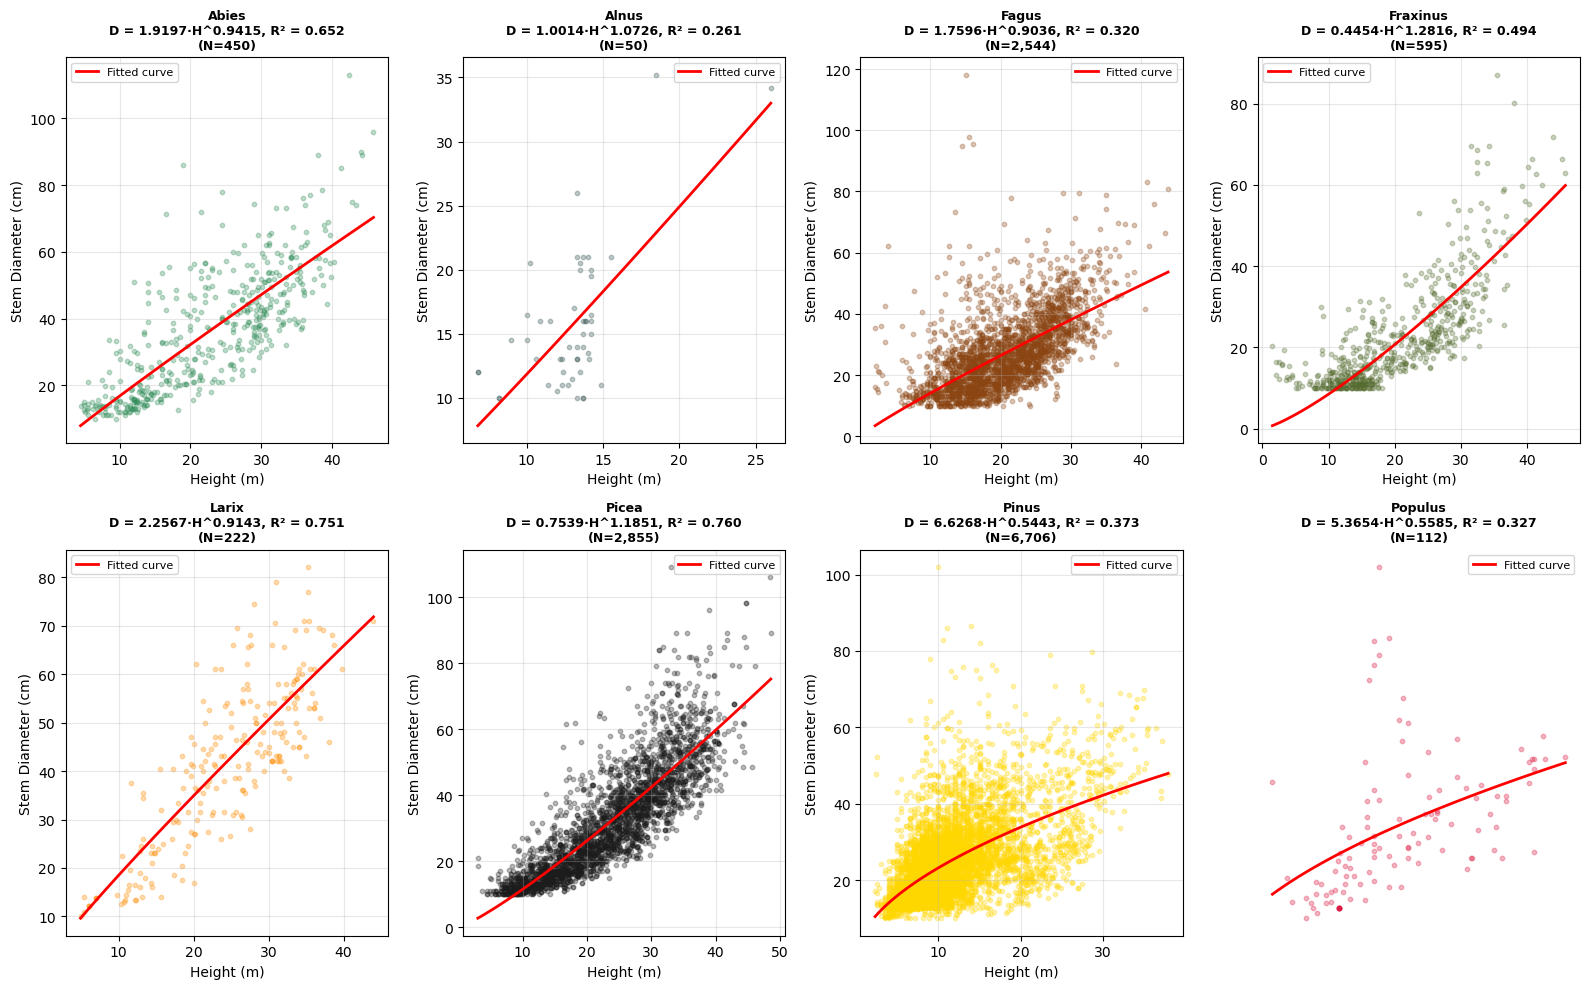

In [11]:
# Visualize D-H curves for geographic subset
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, genus in enumerate(sorted(allometry_results_geo.keys())):
    ax = axes[idx]
    
    genus_data = df_tallo[df_tallo['genus'] == genus].dropna(subset=['stem_diameter_cm', 'height_m'])
    H = genus_data['height_m'].values
    D = genus_data['stem_diameter_cm'].values
    
    result = allometry_results_geo[genus]
    a, b = result['a'], result['b']
    r_sq = result['r_squared']
    
    # Plot raw data
    ax.scatter(H, D, alpha=0.3, s=10, color=colors.get(genus, 'gray'))
    
    # Plot fitted curve
    H_range = np.linspace(H.min(), H.max(), 100)
    D_fitted = allometric_model(H_range, a, b)
    ax.plot(H_range, D_fitted, 'r-', linewidth=2, label=f'Fitted curve')
    
    # Formatting
    ax.set_xlabel('Height (m)', fontsize=10)
    ax.set_ylabel('Stem Diameter (cm)', fontsize=10)
    ax.set_title(f'{genus}\nD = {a:.4f}·H^{b:.4f}, R² = {r_sq:.3f}\n(N={result["n_samples"]:,})', 
                 fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
fig_path_geo = output_base_dir / 'DH_Curves_Geographic_Subset_Genus.png'
plt.savefig(fig_path_geo, dpi=300, bbox_inches='tight')
print('✓ Figure saved: DH_Curves_Geographic_Subset_Genus.png')
plt.show()

In [12]:
# Create summary table for GEOGRAPHIC SUBSET
summary_data_geo = []
for genus, result in sorted(allometry_results_geo.items()):
    summary_data_geo.append({
        'Genus': genus,
        'Formula': f"D = {result['a']:.4f} × H^{result['b']:.4f}",
        'a': result['a'],
        'b': result['b'],
        'R²': result['r_squared'],
        'N samples': result['n_samples'],
        'H min (m)': result['H_min'],
        'H max (m)': result['H_max'],
        'D min (cm)': result['D_min'],
        'D max (cm)': result['D_max']
    })

summary_df_geo = pd.DataFrame(summary_data_geo)

print('\n' + '='*80)
print('ALLOMETRIC MODEL SUMMARY TABLE (GEOGRAPHIC SUBSET - GENISSIAT REGION)')
print('='*80)
print(summary_df_geo.to_string(index=False))

# Export summary to CSV
output_csv_geo = output_base_dir / 'AllometricModels_DH_Geographic_Genus.csv'
summary_df_geo.to_csv(output_csv_geo, index=False)
print(f'\n✓ Summary exported to: {output_csv_geo.name}')
print(f'\n✓ Analysis complete with {len(allometry_results_geo)} generation from the Genissiat region')


ALLOMETRIC MODEL SUMMARY TABLE (GEOGRAPHIC SUBSET - GENISSIAT REGION)
   Genus               Formula        a        b       R²  N samples  H min (m)  H max (m)  D min (cm)  D max (cm)
   Abies D = 1.9197 × H^0.9415 1.919718 0.941472 0.652024        450        4.5       45.8        10.0       113.0
   Alnus D = 1.0014 × H^1.0726 1.001414 1.072649 0.260953         50        6.8       26.0        10.0        35.2
   Fagus D = 1.7596 × H^0.9036 1.759618 0.903619 0.319786       2544        2.1       43.9        10.0       118.1
Fraxinus D = 0.4454 × H^1.2816 0.445356 1.281614 0.493646        595        1.5       45.8        10.0        87.1
   Larix D = 2.2567 × H^0.9143 2.256732 0.914298 0.751474        222        4.9       44.0        10.0        82.0
   Picea D = 0.7539 × H^1.1851 0.753865 1.185076 0.760372       2855        3.0       48.6        10.0       109.0
   Pinus D = 6.6268 × H^0.5443 6.626768 0.544298 0.373409       6706        2.3       37.9        10.0       101.9
 Populus 

In [13]:
# Extract D-H pairs using median values from actual data in specified diameter ranges
# Define diameter classes with their ranges
diameter_classes = {
    'D10-20': (10, 20),
    'D20-30': (20, 30),
    'D30-40': (30, 40),
    'D40-50': (40, 50),
    'D50+': (50, np.inf)
}

print('\n' + '='*80)
print('DIAMETER-HEIGHT PAIRS AT SPECIFIC DIAMETER RANGES')
print('='*80)
print('Method: Calculate median D and H from actual data in specified ranges')
print('(Instead of using inverse allometric curves)\n')

# Create result dictionary
dh_pairs = {}

for genus in sorted(allometry_results_geo.keys()):
    print(f'\n{genus}:')
    genus_pairs = {'Genus': genus}
    genus_data = df_tallo[df_tallo['genus'] == genus].copy()
    
    # Remove NaN values
    genus_data = genus_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    print(f'  Total samples for this genus: {len(genus_data):,}')
    
    for d_class, (d_min, d_max) in diameter_classes.items():
        col_d = d_class
        col_h = d_class.replace('D', 'H')
        
        # Filter data within the diameter range
        if d_max == np.inf:
            data_in_range = genus_data[genus_data['stem_diameter_cm'] >= d_min]
            range_str = f'>= {d_min} cm'
        else:
            data_in_range = genus_data[
                (genus_data['stem_diameter_cm'] >= d_min) & 
                (genus_data['stem_diameter_cm'] < d_max)
            ]
            range_str = f'{d_min}-{d_max} cm'
        
        if len(data_in_range) > 0:
            # Calculate median diameter
            d_median = data_in_range['stem_diameter_cm'].median()
            
            # Find the tree with diameter closest to the median diameter
            median_tree_idx = (data_in_range['stem_diameter_cm'] - d_median).abs().idxmin()
            median_tree = data_in_range.loc[median_tree_idx]
            
            # Get the actual height value from that tree (no calculation)
            d_actual = median_tree['stem_diameter_cm']
            h_actual = median_tree['height_m']
            n_samples = len(data_in_range)
            
            genus_pairs[col_d] = round(d_actual, 2)
            genus_pairs[col_h] = round(h_actual, 2)
            
            print(f'  {d_class} ({range_str}): D={d_actual:.2f} cm, H={h_actual:.2f} m (n={n_samples:,})')
        else:
            # No data in this range
            genus_pairs[col_d] = np.nan
            genus_pairs[col_h] = np.nan
            print(f'  {d_class} ({range_str}): NA (no data in range)')
    
    dh_pairs[genus] = genus_pairs

print('\n' + '='*80)

# Create DataFrame
dh_df = pd.DataFrame([dh_pairs[g] for g in sorted(dh_pairs.keys())])

# Reorder columns for better readability
col_order = ['Genus']
for d_class in diameter_classes.keys():
    col_order.extend([d_class, d_class.replace('D', 'H')])
dh_df = dh_df[col_order]

print('\nD-H PAIRS TABLE (Median values from actual data by diameter range):')
print('='*80)
print(dh_df.to_string(index=False))

# Export to CSV
output_dh = output_base_dir / 'DH_Pairs_DiameterRanges_Genus.csv'
dh_df.to_csv(output_dh, index=False)
print(f'\n✓ Exported to: {output_dh.name}')


DIAMETER-HEIGHT PAIRS AT SPECIFIC DIAMETER RANGES
Method: Calculate median D and H from actual data in specified ranges
(Instead of using inverse allometric curves)


Abies:
  Total samples for this genus: 450
  D10-20 (10-20 cm): D=14.50 cm, H=10.70 m (n=107)
  D20-30 (20-30 cm): D=24.00 cm, H=20.40 m (n=73)
  D30-40 (30-40 cm): D=35.00 cm, H=28.90 m (n=81)
  D40-50 (40-50 cm): D=44.50 cm, H=28.10 m (n=84)
  D50+ (>= 50 cm): D=57.00 cm, H=32.70 m (n=105)

Alnus:
  Total samples for this genus: 50
  D10-20 (10-20 cm): D=13.00 cm, H=12.20 m (n=39)
  D20-30 (20-30 cm): D=21.00 cm, H=15.50 m (n=9)
  D30-40 (30-40 cm): D=34.20 cm, H=26.00 m (n=2)
  D40-50 (40-50 cm): NA (no data in range)
  D50+ (>= 50 cm): NA (no data in range)

Fagus:
  Total samples for this genus: 2,544
  D10-20 (10-20 cm): D=15.10 cm, H=20.80 m (n=803)
  D20-30 (20-30 cm): D=24.50 cm, H=22.60 m (n=891)
  D30-40 (30-40 cm): D=34.10 cm, H=25.60 m (n=503)
  D40-50 (40-50 cm): D=44.00 cm, H=22.50 m (n=227)
  D50+ (>= 50 

In [14]:
import math

# Define VEF equation constants by genus (using values from principal species in each genus)
vef_constants = {
    'Abies': {'b2': 1.496, 'b4': 0.566, 'G': 0},
    'Fagus': {'b2': 0.842, 'b4': 0.627, 'G': 1},
    'Fraxinus': {'b2': 1.112, 'b4': 0.470, 'G': 1},
    'Larix': {'b2': 0.966, 'b4': 0.454, 'G': 0},
    'Pinus': {'b2': 0.566, 'b4': 0.336, 'G': 0},
    'Picea': {'b2': 0.953, 'b4': 0.473, 'G': 0},
    'Alnus': {'b2': 1.015, 'b4': 0.522, 'G': 1},
    'Populus': {'b2': 1.015, 'b4': 0.522, 'G': 1}
}

# Define VEF calculation function
def calculate_vef(DBH_cm, H_m, b2, b4, G):
    """
    Calculate VEF (Form Factor) using the equation:
    VEF = exp(-6.830 * (DBH_cm / 100.0)) / b2 + exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2)) + 1
    """
    if pd.isna(DBH_cm) or pd.isna(H_m):
        return np.nan
    
    try:
        term1 = math.exp(-6.830 * (DBH_cm / 100.0)) / b2
        term2 = math.exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2))
        vef = term1 + term2 + 1
        return vef
    except Exception as e:
        return np.nan

# Define diameter ranges
diameter_classes = {
    'D10-20': 'VEF10-20',
    'D20-30': 'VEF20-30',
    'D30-40': 'VEF30-40',
    'D40-50': 'VEF40-50',
    'D50+': 'VEF50+'
}

print('\n' + '='*100)
print('VEF (FORM FACTOR) CALCULATIONS BY DIAMETER RANGE')
print('='*100)
print('Equation: VEF = exp(-6.830 * (DBH_cm / 100.0)) / b2 + exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2)) + 1\n')

# Create result dataframe
vef_df = dh_df[['Genus']].copy()

# Calculate VEF for each diameter range
for d_class, vef_col in diameter_classes.items():
    col_d = d_class
    col_h = d_class.replace('D', 'H')
    
    vef_df[vef_col] = np.nan
    
    for idx, row in dh_df.iterrows():
        genus = row['Genus']
        
        # Skip if genus not in constants
        if genus not in vef_constants:
            print(f'⚠ {genus}: No VEF constants defined')
            continue
        
        D = row[col_d]
        H = row[col_h]
        
        if pd.notna(D) and pd.notna(H):
            # Get genus constants
            constants = vef_constants[genus]
            b2 = constants['b2']
            b4 = constants['b4']
            G = constants['G']
            
            # Calculate VEF
            vef_value = calculate_vef(D, H, b2, b4, G)
            vef_df.at[idx, vef_col] = round(vef_value, 6) if pd.notna(vef_value) else np.nan

print('\n' + '='*100)
print('VEF SUMMARY TABLE (by diameter range)')
print('='*100)

# Display with better formatting
print(vef_df.to_string(index=False))

# Export to CSV
output_vef = output_base_dir / 'VEF_DiameterRanges_Genus.csv'
vef_df.to_csv(output_vef, index=False)

print(f'\n✓ Exported to: {output_vef.name}')
print(f'  Location: {output_vef.parent}')
print(f'  Rows: {len(vef_df)}')
print(f'  Columns: {list(vef_df.columns)}')


VEF (FORM FACTOR) CALCULATIONS BY DIAMETER RANGE
Equation: VEF = exp(-6.830 * (DBH_cm / 100.0)) / b2 + exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2)) + 1


VEF SUMMARY TABLE (by diameter range)
   Genus  VEF10-20  VEF20-30  VEF30-40  VEF40-50   VEF50+
   Abies  1.471348  1.231339  1.135024  1.131252 1.107508
   Alnus  1.809202  1.638835  1.329173       NaN      NaN
   Fagus  1.602643  1.469118  1.382831  1.505088 1.298894
Fraxinus  1.653744  1.329152  1.252300  1.193875 1.185742
   Larix  1.526335  1.297788  1.412436  1.195867 1.107244
   Picea  1.420642  1.286026  1.155696  1.113415 1.121683
   Pinus  1.996851  1.422604  1.253512  1.154135 1.413303
 Populus  1.871817  1.573570  1.270894  1.456519 1.983559

✓ Exported to: VEF_DiameterRanges_Genus.csv
  Location: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus
  Rows: 8
  Columns: ['Genus', 'VEF10-20', 'VEF20-30', 'VEF30-40', 'VEF40-50', 'VEF50+']


In [15]:
# Calculate VEFm (conservative approach using customizable percentile ranges)
print('\n' + '='*100)
print('VEFm (CONSERVATIVE FORM FACTOR) - CUSTOMIZABLE PERCENTILE APPROACH')
print('='*100)
print('Method: Calculate VEF for all samples in each diameter range,')
print('        extract P_min-P_max percentile range per genus, and take median\n')

# CONFIGURE PERCENTILE RANGES PER GENUS
# Change these values to customize the percentile range for each genus
percentile_ranges = {
    'Abies': (5, 15),        # P5-P25
    'Fagus': (5, 25),        # P5-P25
    'Fraxinus': (5, 15),     # P5-P25
    'Larix': (5, 20),        # P5-P25
    'Pinus': (5, 10),        # P5-P25
    'Picea': (5, 15),        # P5-P25
    'Alnus': (5, 10),        # P5-P25
    'Populus': (5, 10)       # P5-P25
}

print('Percentile ranges configured by genus:')
for genus, (p_min, p_max) in sorted(percentile_ranges.items()):
    print(f'  {genus}: P{p_min}-P{p_max}')

# Define diameter ranges again for clarity
diameter_classes_vefm = {
    'D10-20': (10, 20),
    'D20-30': (20, 30),
    'D30-40': (30, 40),
    'D40-50': (40, 50),
    'D50+': (50, np.inf)
}

# Create result dataframe
vefm_df = pd.DataFrame()
vefm_df['Genus'] = sorted(df_tallo_geo['genus'].unique())

# For each genus and diameter class
for d_class, (d_min, d_max) in diameter_classes_vefm.items():
    vefm_col = d_class.replace('D', 'VEFm')
    vefm_df[vefm_col] = np.nan
    
    print(f'\n{d_class} ({d_min}-{d_max if d_max != np.inf else "∞"} cm):')
    
    for idx, genus in enumerate(vefm_df['Genus']):
        # Get all samples for this genus in this diameter range
        genus_data = df_tallo_geo[df_tallo_geo['genus'] == genus].copy()
        
        # Filter by diameter range
        if d_max == np.inf:
            data_in_range = genus_data[genus_data['stem_diameter_cm'] >= d_min]
        else:
            data_in_range = genus_data[
                (genus_data['stem_diameter_cm'] >= d_min) & 
                (genus_data['stem_diameter_cm'] < d_max)
            ]
        
        data_in_range = data_in_range.dropna(subset=['stem_diameter_cm', 'height_m'])
        
        n_samples = len(data_in_range)
        
        if n_samples == 0:
            vefm_df.at[idx, vefm_col] = np.nan
            print(f'  {genus}: No samples in range')
            continue
        
        # Get genus constants
        if genus not in vef_constants:
            print(f'  {genus}: No VEF constants defined')
            continue
        
        constants = vef_constants[genus]
        b2 = constants['b2']
        b4 = constants['b4']
        G = constants['G']
        
        # Calculate VEF for all samples in this range
        vef_values = []
        for _, sample_row in data_in_range.iterrows():
            D = sample_row['stem_diameter_cm']
            H = sample_row['height_m']
            vef_val = calculate_vef(D, H, b2, b4, G)
            if pd.notna(vef_val):
                vef_values.append(vef_val)
        
        if len(vef_values) == 0:
            vefm_df.at[idx, vefm_col] = np.nan
            print(f'  {genus}: Could not calculate VEF values')
            continue
        
        vef_values = np.array(vef_values)
        
        # Get percentile range for this genus
        p_min, p_max = percentile_ranges.get(genus, (5, 25))
        
        # Extract P_min-P_max range
        p_min_val = np.percentile(vef_values, p_min)
        p_max_val = np.percentile(vef_values, p_max)
        
        # Filter to P_min-P_max
        vef_p_range = vef_values[(vef_values >= p_min_val) & (vef_values <= p_max_val)]
        
        # Take median of P_min-P_max
        vefm_conservative = np.median(vef_p_range)
        
        vefm_df.at[idx, vefm_col] = round(vefm_conservative, 6)
        
        print(f'  {genus}: n={n_samples:5d} | P{p_min}={p_min_val:.4f} P{p_max}={p_max_val:.4f} | ' + 
              f'VEFm(P{p_min}-P{p_max} median)={vefm_conservative:.6f}')

print('\n' + '='*100)
print('VEFm CONSERVATIVE SUMMARY TABLE (Custom percentile ranges by genus)')
print('='*100)

# Display with better formatting
print(vefm_df.to_string(index=False))

# Export to CSV
output_vefm = output_base_dir / 'VEFm_DiameterRanges_Genus_Conservative2.csv'
vefm_df.to_csv(output_vefm, index=False)

print(f'\n✓ Exported to: {output_vefm.name}')
print(f'  Location: {output_vefm.parent}')
print(f'  Rows: {len(vefm_df)} genera')
print(f'  Columns: {list(vefm_df.columns)}')

# Create comparison table (VEF vs VEFm)
print('\n' + '='*100)
print('COMPARISON: VEF (original) vs VEFm (conservative with custom percentile ranges)')
print('='*100)

comparison_cols = ['Genus']
for d_class in diameter_classes_vefm.keys():
    comparison_cols.append(d_class.replace('D', 'VEF'))
    comparison_cols.append(d_class.replace('D', 'VEFm'))
    comparison_cols.append(d_class.replace('D', 'Diff%'))

comparison_df = vef_df[['Genus']].copy()

for d_class in diameter_classes_vefm.keys():
    vef_col = d_class.replace('D', 'VEF')
    vefm_col = d_class.replace('D', 'VEFm')
    diff_col = d_class.replace('D', 'Diff%')
    
    comparison_df[vef_col] = vef_df[vef_col]
    comparison_df[vefm_col] = vefm_df[vefm_col]
    
    # Calculate percentage difference: (VEFm - VEF) / VEF * 100
    comparison_df[diff_col] = ((vefm_df[vefm_col] - vef_df[vef_col]) / vef_df[vef_col] * 100).round(1)

print(comparison_df.to_string(index=False))

print(f'\n✓ Comparison complete')


VEFm (CONSERVATIVE FORM FACTOR) - CUSTOMIZABLE PERCENTILE APPROACH
Method: Calculate VEF for all samples in each diameter range,
        extract P_min-P_max percentile range per genus, and take median

Percentile ranges configured by genus:
  Abies: P5-P15
  Alnus: P5-P10
  Fagus: P5-P25
  Fraxinus: P5-P15
  Larix: P5-P20
  Picea: P5-P15
  Pinus: P5-P10
  Populus: P5-P10

D10-20 (10-20 cm):
  Abies: n=  107 | P5=1.3140 P15=1.3511 | VEFm(P5-P15 median)=1.339334
  Alnus: n=   39 | P5=1.6975 P10=1.7052 | VEFm(P5-P10 median)=1.697536
  Fagus: n=  803 | P5=1.5210 P25=1.6424 | VEFm(P5-P25 median)=1.583026
  Fraxinus: n=  324 | P5=1.4056 P15=1.4848 | VEFm(P5-P15 median)=1.451754
  Larix: n=   30 | P5=1.3923 P20=1.4660 | VEFm(P5-P20 median)=1.456671
  Picea: n=  826 | P5=1.3752 P15=1.4157 | VEFm(P5-P15 median)=1.392213
  Pinus: n= 2733 | P5=1.6638 P10=1.7225 | VEFm(P5-P10 median)=1.698110
  Populus: n=   36 | P5=1.5512 P10=1.6043 | VEFm(P5-P10 median)=1.577496

D20-30 (20-30 cm):
  Abies: n= 

c:\Users\jdelhoyo\anaconda3\envs\woodrf\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jdelhoyo\anaconda3\envs\woodrf\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  Pinus: n= 2545 | P5=1.3864 P10=1.4332 | VEFm(P5-P10 median)=1.410182
  Populus: n=   35 | P5=1.3188 P10=1.3356 | VEFm(P5-P10 median)=1.328755

D30-40 (30-40 cm):
  Abies: n=   81 | P5=1.1048 P15=1.1253 | VEFm(P5-P15 median)=1.112466
  Alnus: n=    2 | P5=1.3409 P10=1.3527 | VEFm(P5-P10 median)=nan
  Fagus: n=  503 | P5=1.2889 P25=1.3384 | VEFm(P5-P25 median)=1.316855
  Fraxinus: n=   69 | P5=1.2155 P15=1.2283 | VEFm(P5-P15 median)=1.222970
  Larix: n=   34 | P5=1.1549 P20=1.1694 | VEFm(P5-P20 median)=1.167878
  Picea: n=  536 | P5=1.1364 P15=1.1460 | VEFm(P5-P15 median)=1.141526
  Pinus: n=  867 | P5=1.2397 P10=1.2734 | VEFm(P5-P10 median)=1.258210
  Populus: n=   21 | P5=1.2418 P10=1.2709 | VEFm(P5-P10 median)=1.256363

D40-50 (40-50 cm):
  Abies: n=   84 | P5=1.0921 P15=1.1055 | VEFm(P5-P15 median)=1.102122
  Alnus: No samples in range
  Fagus: n=  227 | P5=1.2615 P25=1.3198 | VEFm(P5-P25 median)=1.297980
  Fraxinus: n=   24 | P5=1.1863 P15=1.1936 | VEFm(P5-P15 median)=1.190601
  L

c:\Users\jdelhoyo\anaconda3\envs\woodrf\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jdelhoyo\anaconda3\envs\woodrf\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  Picea: n=  448 | P5=1.0965 P15=1.1057 | VEFm(P5-P15 median)=1.102071
  Pinus: n=  370 | P5=1.1443 P10=1.1561 | VEFm(P5-P10 median)=1.149880
  Populus: n=   13 | P5=1.2156 P10=1.2237 | VEFm(P5-P10 median)=1.222983

D50+ (50-∞ cm):
  Abies: n=  105 | P5=1.0802 P15=1.0845 | VEFm(P5-P15 median)=1.082057
  Alnus: No samples in range
  Fagus: n=  120 | P5=1.2328 P25=1.2820 | VEFm(P5-P25 median)=1.259699
  Fraxinus: n=   30 | P5=1.1564 P15=1.1699 | VEFm(P5-P15 median)=1.168652
  Larix: n=   75 | P5=1.0862 P20=1.0969 | VEFm(P5-P20 median)=1.091391
  Picea: n=  413 | P5=1.0755 P15=1.0828 | VEFm(P5-P15 median)=1.079802
  Pinus: n=  191 | P5=1.1012 P10=1.1143 | VEFm(P5-P10 median)=1.110187
  Populus: n=    7 | P5=1.7409 P10=1.8183 | VEFm(P5-P10 median)=nan

VEFm CONSERVATIVE SUMMARY TABLE (Custom percentile ranges by genus)
   Genus  VEFm10-20  VEFm20-30  VEFm30-40  VEFm40-50  VEFm50+
   Abies   1.339334   1.185345   1.112466   1.102122 1.082057
   Alnus   1.697536        NaN        NaN        

c:\Users\jdelhoyo\anaconda3\envs\woodrf\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jdelhoyo\anaconda3\envs\woodrf\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [16]:
# Calculate volume for each genus using provided equations
print('\n' + '='*80)
print('VOLUME CALCULATIONS USING GENUS-SPECIFIC EQUATIONS')
print('='*80)

# Define diameter classes
diameter_classes = {
    'D10-20': (10, 20),
    'D20-30': (20, 30),
    'D30-40': (30, 40),
    'D40-50': (40, 50),
    'D50+': (50, np.inf)
}

# Define volume equations for each genus (using principles species coefficients)
volume_equations = {
    'Fagus': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.049, 'b': 1.78189, 'c': 1.08345},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Alnus': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H (result in dm³)',
        'params': {'a': 8.6524, 'b': 0.07684, 'c': 0.03157},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Fraxinus': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H + d*D*(H^2) + e*(H^2) (result in dm³)',
        'params': {'a': -1.86827, 'b': 0.21461, 'c': 0.01283, 'd': 0.01380, 'e': -0.06311},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H + p['d']*D*(H**2) + p['e']*(H**2)) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Populus': {
        'model': 'V = a + b*(D^2)*H (result in dm³)',
        'params': {'a': 9.69, 'b': 0.0365},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Pinus': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H (result in dm³)',
        'params': {'a': 8.6524, 'b': 0.07684, 'c': 0.03157},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Larix': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.0983, 'b': 1.551, 'c': 1.1483},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Picea': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.0983, 'b': 1.551, 'c': 1.1483},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Abies': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.0983, 'b': 1.551, 'c': 1.1483},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    }
}

# Add volume columns to dh_df
for d_class in diameter_classes.keys():
    col_v = d_class.replace('D', 'V')
    dh_df[col_v] = np.nan

# Calculate volumes for each genus
for idx, row in dh_df.iterrows():
    genus = row['Genus']
    if genus not in volume_equations:
        print(f'⚠ {genus}: No equation defined')
        continue
    
    eq = volume_equations[genus]
    print(f'\n{genus}')
    
    for d_class in diameter_classes.keys():
        col_d = d_class
        col_h = d_class.replace('D', 'H')
        col_v = d_class.replace('D', 'V')
        
        d_val = row[col_d]
        h_val = row[col_h]
        
        if pd.notna(h_val):
            v_val = eq['func'](d_val, h_val, eq['params'])
            dh_df.at[idx, col_v] = round(v_val, 4)
            print(f'  {col_v}: D={d_val}, H={h_val:.2f} → V={v_val:.4f} m³')

print(f'\n✓ Volume calculations complete')


VOLUME CALCULATIONS USING GENUS-SPECIFIC EQUATIONS

Abies
  V10-20: D=14.5, H=10.70 → V=0.0946 m³
  V20-30: D=24.0, H=20.40 → V=0.4336 m³
  V30-40: D=35.0, H=28.90 → V=1.1613 m³
  V40-50: D=44.5, H=28.10 → V=1.6320 m³
  V50+: D=57.0, H=32.70 → V=2.8515 m³

Alnus
  V10-20: D=13.0, H=12.20 → V=0.0867 m³
  V20-30: D=21.0, H=15.50 → V=0.2583 m³
  V30-40: D=34.2, H=26.00 → V=1.0586 m³

Fagus
  V10-20: D=15.1, H=20.80 → V=0.1656 m³
  V20-30: D=24.5, H=22.60 → V=0.4292 m³
  V30-40: D=34.1, H=25.60 → V=0.8854 m³
  V40-50: D=44.0, H=22.50 → V=1.2125 m³
  V50+: D=55.7, H=32.40 → V=2.7398 m³

Fraxinus
  V10-20: D=12.8, H=14.20 → V=0.0860 m³
  V20-30: D=23.6, H=26.30 → V=0.4872 m³
  V30-40: D=33.6, H=30.20 → V=1.0432 m³
  V40-50: D=44.8, H=36.00 → V=2.0753 m³
  V50+: D=59.7, H=39.20 → V=3.7245 m³

Larix
  V10-20: D=14.0, H=13.10 → V=0.1130 m³
  V20-30: D=24.5, H=19.30 → V=0.4201 m³
  V30-40: D=35.5, H=13.20 → V=0.4827 m³
  V40-50: D=43.5, H=21.90 → V=1.1833 m³
  V50+: D=58.0, H=32.30 → V=2.8883 m

In [17]:
# Display summary table with volumes
print('\n' + '='*80)
print('VOLUME SUMMARY TABLE (D-H-V)')
print('='*80)

# Display with better formatting
display_df = dh_df.copy()

# Round numeric columns for display
for col in display_df.columns:
    if col != 'Genus':
        display_df[col] = display_df[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'NA')

print(display_df.to_string(index=False))
print(f'\n✓ File processed: DHV_DiameterRanges_Genus')
print(f'\n✓ Calculations complete!')
print(f'  - {len(dh_df)} genera with diameter-height-volume relationships')
print(f'  - 5 diameter ranges per genus (10-20, 20-30, 30-40, 40-50, 50+ cm)')
print(f'  - Volumes in m³')


VOLUME SUMMARY TABLE (D-H-V)
   Genus D10-20 H10-20 D20-30 H20-30 D30-40 H30-40 D40-50 H40-50  D50+  H50+ V10-20 V20-30 V30-40 V40-50 V50+
   Abies  14.50  10.70  24.00  20.40  35.00  28.90  44.50  28.10 57.00 32.70   0.09   0.43   1.16   1.63 2.85
   Alnus  13.00  12.20  21.00  15.50  34.20  26.00     NA     NA    NA    NA   0.09   0.26   1.06     NA   NA
   Fagus  15.10  20.80  24.50  22.60  34.10  25.60  44.00  22.50 55.70 32.40   0.17   0.43   0.89   1.21 2.74
Fraxinus  12.80  14.20  23.60  26.30  33.60  30.20  44.80  36.00 59.70 39.20   0.09   0.49   1.04   2.08 3.72
   Larix  14.00  13.10  24.50  19.30  35.50  13.20  43.50  21.90 58.00 32.30   0.11   0.42   0.48   1.18 2.89
   Picea  15.00  23.40  24.50  21.00  35.00  30.70  44.00  33.90 57.00 30.20   0.24   0.46   1.24   1.99 2.60
   Pinus  15.60   7.50  24.60  19.20  33.40  25.30  44.20  30.20 56.50 14.50   0.09   0.42   0.99   2.02 1.72
 Populus  14.40  11.50  23.40  17.00  33.50  30.10  41.90  22.00 60.50 17.00   0.10   0.35

In [18]:
# Calculate shape factors (f) for original volumes
print('\n' + '='*80)
print('SHAPE FACTORS (f) FOR ORIGINAL VOLUME EQUATIONS')
print('='*80)
print('Formula: f = V / ((π/4) * D² * H)')
print('f represents the ratio of actual volume to ideal cylinder volume\n')

# Define diameter ranges and their corresponding shape factor column names
diameter_classes_f = {
    'D10-20': 'f10-20',
    'D20-30': 'f20-30',
    'D30-40': 'f30-40',
    'D40-50': 'f40-50',
    'D50+': 'f50+'
}

# Create DataFrame for shape factors
dh_df_f = pd.DataFrame()
dh_df_f['Genus'] = dh_df['Genus']

# Add the shape factor columns
for d_class, f_col_name in diameter_classes_f.items():
    dh_df_f[f_col_name] = np.nan

# Calculate shape factors for each genus
for idx, row in dh_df.iterrows():
    genus = row['Genus']
    print(f'\n{genus}:')
    
    for d_class, f_col_name in diameter_classes_f.items():
        col_d = d_class
        col_h = d_class.replace('D', 'H')
        col_v = d_class.replace('D', 'V')
        
        d_val = row[col_d]
        h_val = row[col_h]
        v_val = row[col_v]
        
        if pd.notna(d_val) and pd.notna(h_val) and pd.notna(v_val):
            # Convert D from cm to m
            d_m = d_val / 100  # Convert cm to m
            # Calculate cylinder volume: (π/4) * D² * H (in m³)
            v_cylinder = (np.pi / 4) * (d_m**2) * h_val  # m³
            
            # Calculate shape factor
            f_val = v_val / v_cylinder
            dh_df_f.at[idx, f_col_name] = round(f_val, 5)
            print(f'  {d_class} ({f_col_name}): V={v_val:.4f} m³ / V_cyl={v_cylinder:.4f} m³ → f={f_val:.5f}')
        else:
            dh_df_f.at[idx, f_col_name] = np.nan
            print(f'  {d_class} ({f_col_name}): NA (missing D, H, or V values)')

print('\n' + '='*80)
print('\nFINAL SHAPE FACTORS TABLE (diameter ranges: 10-20, 20-30, 30-40, 40-50, 50+ cm):')
print('='*80)
print(dh_df_f.to_string(index=False))

# Export shape factors to CSV
output_factors = output_base_dir / 'ShapeFactors_Original_Genus.csv'
dh_df_f.to_csv(output_factors, index=False)
print(f'\n✓ Exported to: {output_factors.name}')
print(f'  Rows: {len(dh_df_f)} genera')
print(f'  Columns: {list(dh_df_f.columns)}')


SHAPE FACTORS (f) FOR ORIGINAL VOLUME EQUATIONS
Formula: f = V / ((π/4) * D² * H)
f represents the ratio of actual volume to ideal cylinder volume


Abies:
  D10-20 (f10-20): V=0.0946 m³ / V_cyl=0.1767 m³ → f=0.53540
  D20-30 (f20-30): V=0.4336 m³ / V_cyl=0.9229 m³ → f=0.46984
  D30-40 (f30-40): V=1.1613 m³ / V_cyl=2.7805 m³ → f=0.41766
  D40-50 (f40-50): V=1.6320 m³ / V_cyl=4.3704 m³ → f=0.37343
  D50+ (f50+): V=2.8515 m³ / V_cyl=8.3443 m³ → f=0.34173

Alnus:
  D10-20 (f10-20): V=0.0867 m³ / V_cyl=0.1619 m³ → f=0.53541
  D20-30 (f20-30): V=0.2583 m³ / V_cyl=0.5369 m³ → f=0.48113
  D30-40 (f30-40): V=1.0586 m³ / V_cyl=2.3884 m³ → f=0.44322
  D40-50 (f40-50): NA (missing D, H, or V values)
  D50+ (f50+): NA (missing D, H, or V values)

Fagus:
  D10-20 (f10-20): V=0.1656 m³ / V_cyl=0.3725 m³ → f=0.44458
  D20-30 (f20-30): V=0.4292 m³ / V_cyl=1.0654 m³ → f=0.40284
  D30-40 (f30-40): V=0.8854 m³ / V_cyl=2.3380 m³ → f=0.37870
  D40-50 (f40-50): V=1.2125 m³ / V_cyl=3.4212 m³ → f=0.35441
  D

In [19]:
# Confirm all genera included
print('✓ All genera included in analysis')
print(f'Genera: {list(dh_df["Genus"].unique())}')

✓ All genera included in analysis
Genera: ['Abies', 'Alnus', 'Fagus', 'Fraxinus', 'Larix', 'Picea', 'Pinus', 'Populus']


In [20]:
# Load DefinitiveRV4 dataset for relating shape factors
print('\n' + '='*80)
print('LOADING DEFINITIVE RV4 DATA WITH CONIFERS')
print('='*80)

definitive_rv4_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\DefinitiveRV4(withconifers).csv')
df_rv4 = pd.read_csv(definitive_rv4_path)

print(f'\n✓ Data loaded successfully from: {definitive_rv4_path}')
print(f'\nShape: {df_rv4.shape}')
print(f'\nColumns:')
for i, col in enumerate(df_rv4.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nFirst 5 rows:')
print(df_rv4.head())

print(f'\nData types:')
print(df_rv4.dtypes)

print(f'\nBasic statistics:')
print(df_rv4.describe())


LOADING DEFINITIVE RV4 DATA WITH CONIFERS

✓ Data loaded successfully from: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\DefinitiveRV4(withconifers).csv

Shape: (89, 153)

Columns:
   1. Id_Data
   2. Id_Place
   3. Basin
   4. Sub_Basin
   5. Stand_Code
   6. Bank
   7. Cod_Plg
   8. Standing_Dead_Trees
   9. Dead_Wood
  10. Regeneration
  11. Lat_Connectivity
  12. LW_Presence
  13. Lentgh (m)
  14. Distance (m)
  15. Sinuosity
  16. Sinuosity 1.1 y 1.4
  17. Gradient (m)
  18. Gradient (%)
  19. Gradient (class) (0.2%,2%)
  20. Width_classes
  21. Width_Mean
  22. Width_error
  23. Width/Height
  24. Flow Acc (m)
  25. SPI (b0.5)
  26. SPI / Width
  27. SPI * Width/Height
  28. Surface (ha)
  29. Distance to outlet (km)
  30. Basal_Area (m2/ha)
  31. P25_Height
  32. P50_Height
  33. P75_Height
  34. Vol 30m
  35. Gr. Connect
  36. Gr. Slope
  37. Gr.Width
  38. Gr. Sinuo
  39. Gr. Index
  40. Invasive (Y_N)
  41. SoftWood_Ab
  42. Pioneers_Ab
  

In [21]:
# Load ShapeFactors_Original.csv
print('\n' + '='*80)
print('LOADING SHAPE FACTORS DATA')
print('='*80)

shape_factors_path = output_base_dir / 'ShapeFactors_Original_Genus.csv'
dh_df_f = pd.read_csv(shape_factors_path)

print(f'\n✓ Shape factors loaded successfully from: {shape_factors_path}')
print(f'\nShape: {dh_df_f.shape}')
print(f'\nColumns:')
for i, col in enumerate(dh_df_f.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nData:')
print(dh_df_f)

# Clean column names (remove leading/trailing spaces)
dh_df_f.columns = dh_df_f.columns.str.strip()

print(f'\n' + '='*80)
print('OVERVIEW OF SHAPE FACTORS TABLE')
print('='*80)

print(f'\nShapeFactors_Original:')
print(f'  - Rows: {len(dh_df_f)}')
print(f'  - Columns: {len(dh_df_f.columns)}')
print(f'  - Column names: {list(dh_df_f.columns)}')

print(f'\nGenus in ShapeFactors:')
print(dh_df_f['Genus'].unique())

print(f'\nShape factor columns available:')
f_cols = [col for col in dh_df_f.columns if col.startswith('f')]
print(f_cols)


LOADING SHAPE FACTORS DATA

✓ Shape factors loaded successfully from: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus\ShapeFactors_Original_Genus.csv

Shape: (8, 6)

Columns:
   1. Genus
   2. f10-20
   3. f20-30
   4. f30-40
   5. f40-50
   6. f50+

Data:
      Genus   f10-20   f20-30   f30-40   f40-50     f50+
0     Abies  0.53540  0.46984  0.41766  0.37343  0.34173
1     Alnus  0.53541  0.48113  0.44322      NaN      NaN
2     Fagus  0.44458  0.40284  0.37870  0.35441  0.34704
3  Fraxinus  0.47065  0.42348  0.38958  0.36571  0.33942
4     Larix  0.56035  0.46171  0.36945  0.36357  0.33845
5     Picea  0.59224  0.46757  0.42144  0.38591  0.33772
6     Pinus  0.59295  0.46244  0.44454  0.43623  0.47180
7   Populus  0.51631  0.47805  0.46837  0.46791  0.46672

OVERVIEW OF SHAPE FACTORS TABLE

ShapeFactors_Original:
  - Rows: 8
  - Columns: 6
  - Column names: ['Genus', 'f10-20', 'f20-30', 'f30-40', 'f40-50', 'f50+']

Genus in Sh

In [22]:
# Filter DefinitiveRV4 to keep only relevant columns
print('\n' + '='*80)
print('FILTERING DEFINITIVERV4 COLUMNS')
print('='*80)

# Columns to keep explicitly
keep_cols = ['Id_Data', 'Id_Place', 'Basin', 'Sub_Basin', 'Stand_Code', 'Bank', 'Cod_Plg']

# Find all columns starting with 'sp_'
sp_cols = [col for col in df_rv4.columns if col.lower().startswith('sp_')]

# Combine all columns to keep
selected_cols = keep_cols + sp_cols

print(f'\nColumns to keep:')
print(f'  Explicit: {keep_cols}')
print(f'  Starting with "sp_": {sp_cols} ({len(sp_cols)} species columns)')
print(f'\nTotal columns selected: {len(selected_cols)}')

# Filter dataframe
df_rv4_filtered = df_rv4[selected_cols].copy()

print(f'\n✓ Filtered DataFrame shape: {df_rv4_filtered.shape}')
print(f'\nFirst 5 rows:')
print(df_rv4_filtered.head())

print(f'\nColumns in filtered data:')
for i, col in enumerate(df_rv4_filtered.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nData types:')
print(df_rv4_filtered.dtypes)


FILTERING DEFINITIVERV4 COLUMNS

Columns to keep:
  Explicit: ['Id_Data', 'Id_Place', 'Basin', 'Sub_Basin', 'Stand_Code', 'Bank', 'Cod_Plg']
  Starting with "sp_": ['sp_1', 'sp_2', 'sp_3', 'sp_4', 'sp_5', 'sp_6', 'sp_7', 'sp_8', 'sp_9', 'sp_10', 'sp_11', 'sp_12', 'sp_13', 'sp_14', 'sp_15', 'sp_16', 'sp_17', 'sp_18', 'sp_19', 'sp_20', 'sp_21', 'sp_22', 'sp_23', 'sp_24', 'sp_25', 'sp_26', 'sp_27', 'sp_28', 'sp_29', 'sp_1_10-20', 'sp_2_10-20', 'sp_3_10-20', 'sp_4_10-20', 'sp_5_10-20', 'sp_6_10-20', 'sp_7_10-20', 'sp_8_10-20', 'sp_9_10-20', 'sp_13_10-20', 'sp_15_10-20', 'sp_16_10-20', 'sp_18_10-20', 'sp_19_10-20', 'sp_22_10-20', 'sp_25_10-20', 'sp_1_20-30', 'sp_2_20-30', 'sp_3_20-30', 'sp_4_20-30', 'sp_5_20-30', 'sp_6_20-30', 'sp_7_20-30', 'sp_8_20-30', 'sp_9_20-30', 'sp_13_20-30', 'sp_15_20-30', 'sp_16_20-30', 'sp_19_20-30', 'sp_25_20-30', 'sp_1_30-40', 'sp_2_30-40', 'sp_3_30-40', 'sp_4_30-40', 'sp_5_30-40', 'sp_6_30-40', 'sp_8_30-40', 'sp_9_30-40', 'sp_15_30-40', 'sp_16_30-40', 'sp_22_3

In [23]:
# Accumulate shape factors for each RV4 row
print('\n' + '='*80)
print('ACCUMULATING SHAPE FACTORS BY ROW')
print('='*80)

# Mapeo de rangos de diámetro a columnas de f
diameter_range_to_f = {
    '10-20': 'f10-20',
    '20-30': 'f20-30',
    '30-40': 'f30-40',
    '40-50': 'f40-50',
    '>50': 'f50+'
}

# CORRECTED MAPPING: sp_X → Genus names (based on DefinitiveRV4 structure)
genus_mapping = {
    'sp_1': 'conifers',
    'sp_2': 'Populus',
    'sp_4': 'Alnus',
    'sp_5': 'Fraxinus',
    'sp_6': 'Fagus',
    'sp_10': 'Larix',
    'sp_11': 'Pinus',
    'sp_12': 'conifers'
}

print('Genus mapping (sp_X → Genus):')
for sp_code, genus_name in genus_mapping.items():
    print(f'  {sp_code} → {genus_name}')

print(f'\nDiameter range to shape factor mapping:')
for d_range, f_col in diameter_range_to_f.items():
    print(f'  {d_range} cm → {f_col}')

print(f'\nShapeFactors table columns: {list(dh_df_f.columns)}')

print(f'\n✓ Extraction process initiated...\n')

# For each row in df_rv4_filtered
accumulated_factors = []

for idx, row in df_rv4_filtered.iterrows():
    cod_plg = row['Cod_Plg']
    print(f'Processing row {idx}: Cod_Plg = {cod_plg}')
    
    # Get all sp_X columns with value 1 (genus present)
    present_genera = []
    for col in df_rv4_filtered.columns:
        if col.lower().startswith('sp_') and isinstance(row[col], (int, float)):
            if row[col] == 1:
                present_genera.append(col)
    
    print(f'  Present genus codes: {present_genera}')
    
    # For each present genus, find sp_X_Y-Z columns with value 1
    row_shape_factors = []
    
    for sp_col in df_rv4_filtered.columns:
        # Check if this is a diameter-range column (sp_X_Y-Z format)
        if '_' in sp_col and sp_col.lower().startswith('sp_'):
            # Parse the column name: sp_X_Y-Z or sp_X_>Z
            parts = sp_col.split('_')
            if len(parts) >= 2:
                sp_code = f'sp_{parts[1]}'  # e.g., "sp_4" from "sp_4_10-20"
                d_range = '_'.join(parts[2:]) if len(parts) > 2 else None  # e.g., "10-20"
                
                # Check if this genus is in genus_mapping and has value 1
                if sp_code in genus_mapping and pd.notna(row[sp_col]) and row[sp_col] == 1:
                    genus_name = genus_mapping[sp_code]
                    f_col = diameter_range_to_f.get(d_range, None)
                    
                    if f_col and genus_name in dh_df_f['Genus'].values:
                        # Get the shape factor value
                        f_value = dh_df_f[dh_df_f['Genus'] == genus_name][f_col].values
                        
                        if len(f_value) > 0 and pd.notna(f_value[0]):
                            row_shape_factors.append({
                                'sp_code': sp_code,
                                'genus': genus_name,
                                'diameter_range': d_range,
                                'f_column': f_col,
                                'f_value': float(f_value[0])
                            })
                            print(f'    ✓ {sp_col}: {sp_code} ({genus_name}) {d_range} → {f_col} = {f_value[0]:.5f}')
    
    accumulated_factors.append({
        'Cod_Plg': cod_plg,
        'Row_Index': idx,
        'Shape_Factors': row_shape_factors
    })
    
    print(f'  Total factors accumulated: {len(row_shape_factors)}\n')

print('='*80)
print(f'\n✓ Shape factors extracted for all {len(accumulated_factors)} rows\n')


ACCUMULATING SHAPE FACTORS BY ROW
Genus mapping (sp_X → Genus):
  sp_1 → conifers
  sp_2 → Populus
  sp_4 → Alnus
  sp_5 → Fraxinus
  sp_6 → Fagus
  sp_10 → Larix
  sp_11 → Pinus
  sp_12 → conifers

Diameter range to shape factor mapping:
  10-20 cm → f10-20
  20-30 cm → f20-30
  30-40 cm → f30-40
  40-50 cm → f40-50
  >50 cm → f50+

ShapeFactors table columns: ['Genus', 'f10-20', 'f20-30', 'f30-40', 'f40-50', 'f50+']

✓ Extraction process initiated...

Processing row 0: Cod_Plg = A-A1-Left
  Present genus codes: ['sp_1', 'sp_3', 'sp_4', 'sp_5', 'sp_10', 'sp_12', 'sp_15', 'sp_17', 'sp_23', 'sp_1_10-20', 'sp_4_10-20', 'sp_5_10-20', 'sp_15_10-20', 'sp_4_20-30', 'sp_5_20-30', 'sp_10_20-30', 'sp_10_30-40', 'sp_12_20-30', 'sp_12_40-50']
    ✓ sp_4_10-20: sp_4 (Alnus) 10-20 → f10-20 = 0.53541
    ✓ sp_5_10-20: sp_5 (Fraxinus) 10-20 → f10-20 = 0.47065
    ✓ sp_4_20-30: sp_4 (Alnus) 20-30 → f20-30 = 0.48113
    ✓ sp_5_20-30: sp_5 (Fraxinus) 20-30 → f20-30 = 0.42348
    ✓ sp_10_20-30: sp_10 (L

In [24]:
# Display accumulated shape factors for the first 3 rows with proper structure
print('\n' + '='*100)
print('ACCUMULATED SHAPE FACTORS - FIRST 3 ROWS')
print('='*100)

for i in range(min(3, len(accumulated_factors))):
    factors_dict = accumulated_factors[i]
    print(f'\n{"-"*100}')
    print(f'ROW {i} | Cod_Plg: {factors_dict.get("Cod_Plg", "N/A")}')
    print(f'{"-"*100}')
    
    # Display each shape factor
    shape_factors_list = factors_dict.get('Shape_Factors', [])
    
    if shape_factors_list:
        accumulated_sum = 0
        for factor in shape_factors_list:
            genus = factor.get('genus', 'Unknown')
            d_range = factor.get('diameter_range', 'N/A')
            f_value = factor.get('f_value', 0)
            accumulated_sum += f_value
            print(f'  {genus:25} | {d_range:>8} cm | f = {f_value:.6f}')
        
        print(f'\n  ACCUMULATED SUM: {accumulated_sum:.6f}')
    else:
        print(f'  [No shape factors found]')

print('\n' + '='*100)


ACCUMULATED SHAPE FACTORS - FIRST 3 ROWS

----------------------------------------------------------------------------------------------------
ROW 0 | Cod_Plg: A-A1-Left
----------------------------------------------------------------------------------------------------
  Alnus                     |    10-20 cm | f = 0.535410
  Fraxinus                  |    10-20 cm | f = 0.470650
  Alnus                     |    20-30 cm | f = 0.481130
  Fraxinus                  |    20-30 cm | f = 0.423480
  Larix                     |    20-30 cm | f = 0.461710
  Larix                     |    30-40 cm | f = 0.369450

  ACCUMULATED SUM: 2.741830

----------------------------------------------------------------------------------------------------
ROW 1 | Cod_Plg: A-A1-Right
----------------------------------------------------------------------------------------------------
  Alnus                     |    10-20 cm | f = 0.535410
  Alnus                     |    20-30 cm | f = 0.481130
  Larix     

In [25]:
# Find statistics about shape factors across all rows
print('\n' + '='*100)
print('SHAPE FACTORS STATISTICS ACROSS ALL ROWS')
print('='*100)

factor_counts = []
for row_data in accumulated_factors:
    num_factors = len(row_data.get('Shape_Factors', []))
    factor_counts.append(num_factors)

min_factors = min(factor_counts) if factor_counts else 0
max_factors = max(factor_counts) if factor_counts else 0
avg_factors = sum(factor_counts) / len(factor_counts) if factor_counts else 0

print(f'\nTotal rows: {len(accumulated_factors)}')
print(f'Minimum factors per row: {min_factors}')
print(f'Maximum factors per row: {max_factors}')
print(f'Average factors per row: {avg_factors:.2f}')

# Find rows with minimum factors
rows_with_min = []
for idx, row_data in enumerate(accumulated_factors):
    if len(row_data.get('Shape_Factors', [])) == min_factors:
        rows_with_min.append((idx, row_data.get('Cod_Plg', 'N/A')))

print(f'\nRows with minimum ({min_factors}) factors:')
for idx, cod_plg in rows_with_min[:10]:  # Show first 10
    print(f'  Row {idx:3d}: {cod_plg}')


SHAPE FACTORS STATISTICS ACROSS ALL ROWS

Total rows: 89
Minimum factors per row: 0
Maximum factors per row: 11
Average factors per row: 5.24

Rows with minimum (0) factors:
  Row  88: nan


In [26]:
# Export shape factors data for observation
print('\n' + '='*100)
print('EXPORTING SHAPE FACTORS DATA')
print('='*100)

# Prepare data for export - flatten the structure
export_data = []

for row_data in accumulated_factors:
    cod_plg = row_data.get('Cod_Plg', '')
    
    # Skip empty rows (NaN or missing data)
    if pd.isna(cod_plg) or str(cod_plg) == 'nan' or str(cod_plg).strip() == '':
        continue
    
    shape_factors = row_data.get('Shape_Factors', [])
    
    # If no factors, skip this row
    if len(shape_factors) == 0:
        continue
    
    # Create a row entry for each genus factor combination
    for factor in shape_factors:
        export_data.append({
            'Cod_Plg': cod_plg,
            'Genus': factor.get('genus', ''),
            'Diameter_Range_cm': factor.get('diameter_range', ''),
            'Shape_Factor_f': factor.get('f_value', 0)
        })

# Create DataFrame
df_export = pd.DataFrame(export_data)

# Export to CSV in results folder
output_path_detailed = output_base_dir / 'shape_factors_detailed.csv'

df_export.to_csv(output_path_detailed, index=False)

print(f'\n✓ Shape factors detailed export: {output_path_detailed.name}')
print(f'  Location: {output_path_detailed.parent}')
print(f'  Rows: {len(df_export):,}')
print(f'\nFirst 15 rows of data:')
print(df_export.head(15))

print(f'\n\nData summary by Cod_Plg:')
summary_by_plot = df_export.groupby('Cod_Plg').agg({
    'Shape_Factor_f': ['count', 'sum', 'mean', 'min', 'max']
}).round(6)
summary_by_plot.columns = ['Num_Factors', 'Sum_f', 'Mean_f', 'Min_f', 'Max_f']
print(summary_by_plot.head(15))


EXPORTING SHAPE FACTORS DATA

✓ Shape factors detailed export: shape_factors_detailed.csv
  Location: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus
  Rows: 466

First 15 rows of data:
       Cod_Plg     Genus Diameter_Range_cm  Shape_Factor_f
0    A-A1-Left     Alnus             10-20         0.53541
1    A-A1-Left  Fraxinus             10-20         0.47065
2    A-A1-Left     Alnus             20-30         0.48113
3    A-A1-Left  Fraxinus             20-30         0.42348
4    A-A1-Left     Larix             20-30         0.46171
5    A-A1-Left     Larix             30-40         0.36945
6   A-A1-Right     Alnus             10-20         0.53541
7   A-A1-Right     Alnus             20-30         0.48113
8   A-A1-Right     Larix             30-40         0.36945
9   A-A1-Right     Larix             40-50         0.36357
10  A-A1-Right     Larix               >50         0.33845
11   A-A2-Left   Populus             10-20      

In [27]:
# Calculate median shape factor for each Cod_Plg
print('\n' + '='*100)
print('MEDIAN SHAPE FACTORS BY COD_PLG')
print('='*100)

# Group by Cod_Plg and calculate statistics
df_median = df_export.groupby('Cod_Plg')['Shape_Factor_f'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
]).round(6)

df_median.columns = ['Num_Values', 'Mean_f', 'Median_f', 'Std_f', 'Min_f', 'Max_f']
df_median = df_median.reset_index()

print(df_median.to_string(index=False))

# Export median summary
output_path_median = output_base_dir / 'shape_factors_by_codplg_median.csv'

df_median.to_csv(output_path_median, index=False)

print(f'\n✓ Median export: {output_path_median.name}')
print(f'  Location: {output_path_median.parent}')
print(f'  Rows: {len(df_median):,}')


MEDIAN SHAPE FACTORS BY COD_PLG
    Cod_Plg  Num_Values   Mean_f  Median_f    Std_f   Min_f   Max_f
  A-A1-Left           6 0.456972  0.466180 0.056085 0.36945 0.53541
 A-A1-Right           5 0.417602  0.369450 0.085758 0.33845 0.53541
 A-A10-Left           2 0.473210  0.473210 0.006845 0.46837 0.47805
A-A10-Right           4 0.482660  0.473210 0.022915 0.46791 0.51631
 A-A11-Left           3 0.487577  0.478050 0.025350 0.46837 0.51631
A-A11-Right           3 0.487577  0.478050 0.025350 0.46837 0.51631
 A-A12-Left           7 0.448819  0.468370 0.058931 0.36571 0.53541
A-A12-Right           5 0.476102  0.478050 0.040318 0.42348 0.53541
 A-A13-Left           7 0.481523  0.478050 0.036179 0.42348 0.53541
A-A13-Right           9 0.478194  0.470650 0.032086 0.42348 0.53541
 A-A14-Left           5 0.475808  0.470650 0.040003 0.42348 0.53541
A-A14-Right           5 0.475808  0.470650 0.040003 0.42348 0.53541
 A-A15-Left           7 0.455613  0.468370 0.047984 0.36571 0.51631
A-A15-Right    

In [ ]:
# Bootstrap CI95 - Load data from exported CSV and calculate
import numpy as np
import pandas as pd
from pathlib import Path

print('\n' + '='*100)
print('BOOTSTRAP CI95 FOR MEDIAN SHAPE FACTORS BY COD_PLG')
print('='*100)

# Read the detailed shape factors CSV
csv_path = output_base_dir / 'shape_factors_detailed.csv'
df_export = pd.read_csv(csv_path)

print(f'✓ Loaded: {csv_path.name}')
print(f'  Rows: {len(df_export):,}\n')

np.random.seed(42)
n_bootstrap = 10000

# Group data by Cod_Plg
grouped = df_export.groupby('Cod_Plg')['Shape_Factor_f'].apply(list).to_dict()

results_ci = []

for cod_plg, f_values in grouped.items():
    f_array = np.array(f_values)
    n = len(f_array)
    
    # Calculate central median
    f_central = np.median(f_array)
    
    print(f'{cod_plg} (n={n})')
    
    if n < 5:
        # Use min/max directly for small samples
        f_lower = np.min(f_array)
        f_upper = np.max(f_array)
        print(f'  → n < 5: Using min/max')
        print(f'    f_central = {f_central:.6f}')
        print(f'    f_lower = {f_lower:.6f} (min)')
        print(f'    f_upper = {f_upper:.6f} (max)')
    else:
        # Bootstrap resampling for larger samples
        bootstrap_medians = []
        for _ in range(n_bootstrap):
            resample = np.random.choice(f_array, size=n, replace=True)
            bootstrap_medians.append(np.median(resample))
        
        bootstrap_medians = np.array(bootstrap_medians)
        f_lower = np.percentile(bootstrap_medians, 2.5)
        f_upper = np.percentile(bootstrap_medians, 97.5)
        
        print(f'  → Bootstrap (n={n_bootstrap}):')
        print(f'    f_central = {f_central:.6f}')
        print(f'    f_lower = {f_lower:.6f} (p2.5)')
        print(f'    f_upper = {f_upper:.6f} (p97.5)')
    
    results_ci.append({
        'Cod_Plg': cod_plg,
        'f_central': round(f_central, 6),
        'f_lower': round(f_lower, 6),
        'f_upper': round(f_upper, 6),
        'n': n
    })

df_ci = pd.DataFrame(results_ci)

print('\n' + '='*100)
print('FINAL CI95 TABLE')
print('='*100)
print(df_ci.to_string(index=False))

# Export to CSV
output_path_ci = output_base_dir / 'shape_factors_ci95_by_codplg.csv'

df_ci.to_csv(output_path_ci, index=False)

print(f'\n✓ CI95 export: {output_path_ci.name}')
print(f'  Location: {output_path_ci.parent}')
print(f'  Rows: {len(df_ci):,}')


BOOTSTRAP CI95 FOR MEDIAN SHAPE FACTORS BY COD_PLG
✓ Loaded: shape_factors_detailed.csv
  Rows: 466

A-A1-Left (n=6)
  → Bootstrap (n=10000):
    f_central = 0.466180
    f_lower = 0.396465 (p2.5)
    f_upper = 0.508270 (p97.5)
A-A1-Right (n=5)
  → Bootstrap (n=10000):
    f_central = 0.369450
    f_lower = 0.338450 (p2.5)
    f_upper = 0.535410 (p97.5)
A-A10-Left (n=2)
  → n < 5: Using min/max
    f_central = 0.473210
    f_lower = 0.468370 (min)
    f_upper = 0.478050 (max)
A-A10-Right (n=4)
  → n < 5: Using min/max
    f_central = 0.473210
    f_lower = 0.467910 (min)
    f_upper = 0.516310 (max)
A-A11-Left (n=3)
  → n < 5: Using min/max
    f_central = 0.478050
    f_lower = 0.468370 (min)
    f_upper = 0.516310 (max)
A-A11-Right (n=3)
  → n < 5: Using min/max
    f_central = 0.478050
    f_lower = 0.468370 (min)
    f_upper = 0.516310 (max)
A-A12-Left (n=7)


In [ ]:

# Define DEFINITIVE VEFm values by genus and diameter range
# This is the final VEFm table to use for RV4 integration
print('\n' + '='*100)
print('LOADING DEFINITIVE VEFm TABLE')
print('='*100)

vefm_definitive_data = {
    'Abies': {'VEFm10-20': 1.339334, 'VEFm20-30': 1.185345, 'VEFm30-40': 1.112466, 'VEFm40-50': 1.102122, 'VEFm50+': 1.082057},
    'Fagus': {'VEFm10-20': 1.583026, 'VEFm20-30': 1.418476, 'VEFm30-40': 1.316855, 'VEFm40-50': 1.29798, 'VEFm50+': 1.259699},
    'Fraxinus': {'VEFm10-20': 1.451754, 'VEFm20-30': 1.279174, 'VEFm30-40': 1.22297, 'VEFm40-50': 1.190601, 'VEFm50+': 1.168652},
    'Larix': {'VEFm10-20': 1.456671, 'VEFm20-30': 1.248814, 'VEFm30-40': 1.167878, 'VEFm40-50': 1.112824, 'VEFm50+': 1.091391},
    'Picea': {'VEFm10-20': 1.392213, 'VEFm20-30': 1.222849, 'VEFm30-40': 1.141526, 'VEFm40-50': 1.102071, 'VEFm50+': 1.079802},
    'Pinus': {'VEFm10-20': 1.3980025, 'VEFm20-30': 1.2170795, 'VEFm30-40': 1.140172, 'VEFm40-50': 1.107473, 'VEFm50+': 1.086724},
    'Alnus': {'VEFm10-20': 1.51739, 'VEFm20-30': 1.348825, 'VEFm30-40': 1.2699125, 'VEFm40-50': 1.2442905, 'VEFm50+': 1.2141755},
    'Populus': {'VEFm10-20': 1.51739, 'VEFm20-30': 1.348825, 'VEFm30-40': 1.2699125, 'VEFm40-50': 1.2442905, 'VEFm50+': 1.2141755}
}

# Convert to DataFrame
vefm_definitive_df = pd.DataFrame([
    {
        'Genus': genus,
        'VEFm10-20': values['VEFm10-20'],
        'VEFm20-30': values['VEFm20-30'],
        'VEFm30-40': values['VEFm30-40'],
        'VEFm40-50': values['VEFm40-50'],
        'VEFm50+': values['VEFm50+']
    }
    for genus, values in vefm_definitive_data.items()
])

print(f'\n✓ VEFm definitive table loaded:')
print(vefm_definitive_df.to_string(index=False))
print(f'\nShape: {vefm_definitive_df.shape}')



LOADING DEFINITIVE VEFm TABLE

✓ VEFm definitive table loaded:
   Genus  VEFm10-20  VEFm20-30  VEFm30-40  VEFm40-50  VEFm50+
   Abies   1.339334   1.185345   1.112466   1.102122 1.082057
   Fagus   1.583026   1.418476   1.316855   1.297980 1.259699
Fraxinus   1.451754   1.279174   1.222970   1.190601 1.168652
   Larix   1.456671   1.248814   1.167878   1.112824 1.091391
   Picea   1.392213   1.222849   1.141526   1.102071 1.079802
   Pinus   1.398003   1.217080   1.140172   1.107473 1.086724
   Alnus   1.517390   1.348825   1.269912   1.244290 1.214176
 Populus   1.517390   1.348825   1.269912   1.244290 1.214176

Shape: (8, 6)


In [ ]:

# Accumulate VEFm for each RV4 row (similar to shape factors)
print('\n' + '='*80)
print('ACCUMULATING VEFm BY ROW FROM DEFINITIVE RV4')
print('='*80)

# Mapping diameter ranges to VEFm columns
diameter_range_to_vefm = {
    '10-20': 'VEFm10-20',
    '20-30': 'VEFm20-30',
    '30-40': 'VEFm30-40',
    '40-50': 'VEFm40-50',
    '>50': 'VEFm50+'
}

# Genus mapping (sp_X → Genus names)
genus_mapping_vefm = {
    'sp_1': 'Picea',          # Conifers -> use Picea as default
    'sp_2': 'Populus',
    'sp_4': 'Alnus',
    'sp_5': 'Fraxinus',
    'sp_6': 'Fagus',
    'sp_10': 'Larix',
    'sp_11': 'Pinus',
    'sp_12': 'Abies'          # Conifers -> use Abies as default
}

print('Genus mapping (sp_X → Genus):')
for sp_code, genus_name in genus_mapping_vefm.items():
    print(f'  {sp_code} → {genus_name}')

print(f'\nDiameter range to VEFm mapping:')
for d_range, vefm_col in diameter_range_to_vefm.items():
    print(f'  {d_range} cm → {vefm_col}')

# For each row in df_rv4_filtered
accumulated_vefm = []

for idx, row in df_rv4_filtered.iterrows():
    cod_plg = row['Cod_Plg']
    
    # Get all sp_X columns with value 1 (genus present)
    present_genera = []
    for col in df_rv4_filtered.columns:
        if col.lower().startswith('sp_') and isinstance(row[col], (int, float)):
            if row[col] == 1 and len(col) <= 4:  # Only sp_X, not sp_X_Y-Z
                present_genera.append(col)
    
    # For each present genus, find sp_X_Y-Z columns with value 1
    row_vefm_values = []
    
    for sp_col in df_rv4_filtered.columns:
        # Check if this is a diameter-range column (sp_X_Y-Z format)
        if '_' in sp_col and sp_col.lower().startswith('sp_'):
            # Parse the column name: sp_X_Y-Z or sp_X_>Z
            parts = sp_col.split('_')
            if len(parts) >= 2:
                sp_code = f'sp_{parts[1]}'  # e.g., "sp_4" from "sp_4_10-20"
                d_range = '_'.join(parts[2:]) if len(parts) > 2 else None  # e.g., "10-20"
                
                # Check if this genus is in genus_mapping and has value 1
                if sp_code in genus_mapping_vefm and pd.notna(row[sp_col]) and row[sp_col] == 1:
                    genus_name = genus_mapping_vefm[sp_code]
                    vefm_col = diameter_range_to_vefm.get(d_range, None)
                    
                    if vefm_col and genus_name in vefm_definitive_df['Genus'].values:
                        # Get the VEFm value
                        vefm_value = vefm_definitive_df[vefm_definitive_df['Genus'] == genus_name][vefm_col].values
                        
                        if len(vefm_value) > 0 and pd.notna(vefm_value[0]):
                            row_vefm_values.append({
                                'sp_code': sp_code,
                                'genus': genus_name,
                                'diameter_range': d_range,
                                'vefm_column': vefm_col,
                                'vefm_value': float(vefm_value[0])
                            })
    
    accumulated_vefm.append({
        'Cod_Plg': cod_plg,
        'Row_Index': idx,
        'VEFm_Values': row_vefm_values
    })

print(f'\n✓ VEFm accumulated for {len(accumulated_vefm)} rows')



ACCUMULATING VEFm BY ROW FROM DEFINITIVE RV4
Genus mapping (sp_X → Genus):
  sp_1 → Picea
  sp_2 → Populus
  sp_4 → Alnus
  sp_5 → Fraxinus
  sp_6 → Fagus
  sp_10 → Larix
  sp_11 → Pinus
  sp_12 → Abies

Diameter range to VEFm mapping:
  10-20 cm → VEFm10-20
  20-30 cm → VEFm20-30
  30-40 cm → VEFm30-40
  40-50 cm → VEFm40-50
  >50 cm → VEFm50+

✓ VEFm accumulated for 89 rows


In [ ]:

# Display first 3 rows of accumulated VEFm
print('\n' + '='*80)
print('FIRST 3 ROWS: ACCUMULATED VEFm')
print('='*80)

for i in range(min(3, len(accumulated_vefm))):
    row_data = accumulated_vefm[i]
    print(f'\nCod_Plg: {row_data["Cod_Plg"]} | Row Index: {row_data["Row_Index"]}')
    print(f'Number of VEFm values: {len(row_data["VEFm_Values"])}')
    
    if row_data['VEFm_Values']:
        print('  VEFm components:')
        for vefm_item in row_data['VEFm_Values']:
            print(f'    • {vefm_item["genus"]:10s} ({vefm_item["diameter_range"]:6s}): VEFm={vefm_item["vefm_value"]:.6f}')
    else:
        print('  No VEFm values found')



FIRST 3 ROWS: ACCUMULATED VEFm

Cod_Plg: A-A1-Left | Row Index: 0
Number of VEFm values: 9
  VEFm components:
    • Picea      (10-20 ): VEFm=1.392213
    • Alnus      (10-20 ): VEFm=1.517390
    • Fraxinus   (10-20 ): VEFm=1.451754
    • Alnus      (20-30 ): VEFm=1.348825
    • Fraxinus   (20-30 ): VEFm=1.279174
    • Larix      (20-30 ): VEFm=1.248814
    • Larix      (30-40 ): VEFm=1.167878
    • Abies      (20-30 ): VEFm=1.185345
    • Abies      (40-50 ): VEFm=1.102122

Cod_Plg: A-A1-Right | Row Index: 1
Number of VEFm values: 6
  VEFm components:
    • Alnus      (10-20 ): VEFm=1.517390
    • Alnus      (20-30 ): VEFm=1.348825
    • Larix      (30-40 ): VEFm=1.167878
    • Larix      (40-50 ): VEFm=1.112824
    • Larix      (>50   ): VEFm=1.091391
    • Abies      (30-40 ): VEFm=1.112466

Cod_Plg: A-A2-Left | Row Index: 2
Number of VEFm values: 5
  VEFm components:
    • Populus    (10-20 ): VEFm=1.517390
    • Alnus      (10-20 ): VEFm=1.517390
    • Populus    (20-30 ): VEFm=1

In [ ]:

# Calculate VEFm statistics across all rows
print('\n' + '='*80)
print('VEFm STATISTICS ACROSS ALL ROWS')
print('='*80)

total_vefm_entries = sum(len(row['VEFm_Values']) for row in accumulated_vefm)
rows_with_vefm = sum(1 for row in accumulated_vefm if len(row['VEFm_Values']) > 0)
rows_without_vefm = len(accumulated_vefm) - rows_with_vefm

print(f'\nTotal RV4 rows processed: {len(accumulated_vefm)}')
print(f'Rows with VEFm values: {rows_with_vefm}')
print(f'Rows without VEFm values: {rows_without_vefm}')
print(f'Total VEFm entries accumulated: {total_vefm_entries}')

# Count by genus
genus_counts = {}
for row in accumulated_vefm:
    for vefm_item in row['VEFm_Values']:
        genus = vefm_item['genus']
        genus_counts[genus] = genus_counts.get(genus, 0) + 1

print(f'\nVEFm entries by genus:')
for genus in sorted(genus_counts.keys()):
    print(f'  {genus:12s}: {genus_counts[genus]:4d} entries')

# Count by diameter range
diameter_counts = {}
for row in accumulated_vefm:
    for vefm_item in row['VEFm_Values']:
        d_range = vefm_item['diameter_range']
        diameter_counts[d_range] = diameter_counts.get(d_range, 0) + 1

print(f'\nVEFm entries by diameter range:')
for d_range in sorted(diameter_counts.keys(), key=lambda x: (x.replace('>50', '60'), x)):
    print(f'  {d_range:8s}: {diameter_counts[d_range]:4d} entries')



VEFm STATISTICS ACROSS ALL ROWS

Total RV4 rows processed: 89
Rows with VEFm values: 88
Rows without VEFm values: 1
Total VEFm entries accumulated: 548

VEFm entries by genus:
  Abies       :   37 entries
  Alnus       :   83 entries
  Fagus       :  111 entries
  Fraxinus    :  105 entries
  Larix       :   17 entries
  Picea       :   45 entries
  Pinus       :   20 entries
  Populus     :  130 entries

VEFm entries by diameter range:
  10-20   :  201 entries
  20-30   :  196 entries
  30-40   :   97 entries
  40-50   :   40 entries
  >50     :   14 entries


In [ ]:

# Export detailed VEFm data to CSV
print('\n' + '='*80)
print('EXPORTING DETAILED VEFm DATA')
print('='*80)

# Flatten the accumulated VEFm data
detailed_vefm_rows = []
for row in accumulated_vefm:
    cod_plg = row['Cod_Plg']
    for vefm_item in row['VEFm_Values']:
        detailed_vefm_rows.append({
            'Cod_Plg': cod_plg,
            'Genus': vefm_item['genus'],
            'Diameter_Range': vefm_item['diameter_range'],
            'VEFm_Column': vefm_item['vefm_column'],
            'VEFm_Value': vefm_item['vefm_value']
        })

df_vefm_detailed = pd.DataFrame(detailed_vefm_rows)

# Export to CSV
output_file_detailed = output_base_dir / 'vefm_by_codplg_detailed.csv'
df_vefm_detailed.to_csv(output_file_detailed, index=False, encoding='utf-8')

print(f'✓ Detailed VEFm data exported to:')
print(f'  {output_file_detailed}')
print(f'\nShape: {df_vefm_detailed.shape[0]} rows × {df_vefm_detailed.shape[1]} columns')
print(f'\nFirst 10 rows:')
print(df_vefm_detailed.head(10).to_string(index=False))



EXPORTING DETAILED VEFm DATA
✓ Detailed VEFm data exported to:
  C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus\vefm_by_codplg_detailed.csv

Shape: 548 rows × 5 columns

First 10 rows:
   Cod_Plg    Genus Diameter_Range VEFm_Column  VEFm_Value
 A-A1-Left    Picea          10-20   VEFm10-20    1.392213
 A-A1-Left    Alnus          10-20   VEFm10-20    1.517390
 A-A1-Left Fraxinus          10-20   VEFm10-20    1.451754
 A-A1-Left    Alnus          20-30   VEFm20-30    1.348825
 A-A1-Left Fraxinus          20-30   VEFm20-30    1.279174
 A-A1-Left    Larix          20-30   VEFm20-30    1.248814
 A-A1-Left    Larix          30-40   VEFm30-40    1.167878
 A-A1-Left    Abies          20-30   VEFm20-30    1.185345
 A-A1-Left    Abies          40-50   VEFm40-50    1.102122
A-A1-Right    Alnus          10-20   VEFm10-20    1.517390


In [ ]:
# Bootstrap CI95 - Load data from exported CSV and calculate (SAME METHOD AS SHAPE FACTORS)
print('\n' + '='*100)
print('BOOTSTRAP CI95 FOR MEDIAN VEFm BY COD_PLG')
print('='*100)

# Read the detailed VEFm CSV
csv_path_vefm = output_base_dir / 'vefm_by_codplg_detailed.csv'
df_vefm_export = pd.read_csv(csv_path_vefm)

print(f'✓ Loaded: {csv_path_vefm.name}')
print(f'  Rows: {len(df_vefm_export):,}\n')

np.random.seed(42)
n_bootstrap = 10000

# Group data by Cod_Plg
grouped_vefm = df_vefm_export.groupby('Cod_Plg')['VEFm_Value'].apply(list).to_dict()

vefm_ci_results = []

for cod_plg, vefm_values in grouped_vefm.items():
    vefm_array = np.array(vefm_values)
    n = len(vefm_array)
    
    # Calculate central median
    vefm_central = np.median(vefm_array)
    
    print(f'{cod_plg} (n={n})')
    
    if n < 5:
        # Use min/max directly for small samples
        vefm_lower = np.min(vefm_array)
        vefm_upper = np.max(vefm_array)
        print(f'  → n < 5: Using min/max')
        print(f'    VEFm_central = {vefm_central:.6f}')
        print(f'    VEFm_lower = {vefm_lower:.6f} (min)')
        print(f'    VEFm_upper = {vefm_upper:.6f} (max)')
    else:
        # Bootstrap resampling for larger samples
        bootstrap_medians = []
        for _ in range(n_bootstrap):
            resample = np.random.choice(vefm_array, size=n, replace=True)
            bootstrap_medians.append(np.median(resample))
        
        bootstrap_medians = np.array(bootstrap_medians)
        vefm_lower = np.percentile(bootstrap_medians, 2.5)
        vefm_upper = np.percentile(bootstrap_medians, 97.5)
        
        print(f'  → Bootstrap (n={n_bootstrap}):')
        print(f'    VEFm_central = {vefm_central:.6f}')
        print(f'    VEFm_lower = {vefm_lower:.6f} (p2.5)')
        print(f'    VEFm_upper = {vefm_upper:.6f} (p97.5)')
    
    vefm_ci_results.append({
        'Cod_Plg': cod_plg,
        'VEFm_central': round(vefm_central, 6),
        'VEFm_lower': round(vefm_lower, 6),
        'VEFm_upper': round(vefm_upper, 6),
        'n': n
    })

df_vefm_ci = pd.DataFrame(vefm_ci_results)

print('\n' + '='*100)
print('FINAL VEFm CI95 TABLE')
print('='*100)
print(df_vefm_ci.to_string(index=False))

# Export to CSV
output_path_vefm_ci = output_base_dir / 'vefm_by_codplg_ci95.csv'

df_vefm_ci.to_csv(output_path_vefm_ci, index=False)

print(f'\n✓ VEFm CI95 export: {output_path_vefm_ci.name}')
print(f'  Location: {output_path_vefm_ci.parent}')
print(f'  Rows: {len(df_vefm_ci):,}')


BOOTSTRAP CI95 FOR MEDIAN VEFm BY COD_PLG
✓ Loaded: vefm_by_codplg_detailed.csv
  Rows: 548

A-A1-Left (n=9)
  → Bootstrap (n=10000):
    VEFm_central = 1.279174
    VEFm_lower = 1.167878 (p2.5)
    VEFm_upper = 1.451754 (p97.5)
A-A1-Right (n=6)
  → Bootstrap (n=10000):
    VEFm_central = 1.140351
    VEFm_lower = 1.101929 (p2.5)
    VEFm_upper = 1.433107 (p97.5)
A-A10-Left (n=3)
  → n < 5: Using min/max
    VEFm_central = 1.269912
    VEFm_lower = 1.222849 (min)
    VEFm_upper = 1.348825 (max)
A-A10-Right (n=4)
  → n < 5: Using min/max
    VEFm_central = 1.309369
    VEFm_lower = 1.244290 (min)
    VEFm_upper = 1.517390 (max)
A-A11-Left (n=3)
  → n < 5: Using min/max
    VEFm_central = 1.348825
    VEFm_lower = 1.269912 (min)
    VEFm_upper = 1.517390 (max)
A-A11-Right (n=4)
  → n < 5: Using min/max
    VEFm_central = 1.309369
    VEFm_lower = 1.222849 (min)
    VEFm_upper = 1.517390 (max)
A-A12-Left (n=7)
  → Bootstrap (n=10000):
    VEFm_central = 1.279174
    VEFm_lower = 1.222970

In [ ]:

# Final summary: VEFm Bootstrap CI95 workflow completion
print('\n' + '='*100)
print('VEFm BOOTSTRAP CI95 WORKFLOW - FINAL SUMMARY')
print('='*100)

print(f'\n📊 BOOTSTRAP CI95 RESULTS:')
print(f'✓ Bootstrap CI95 calculated for {len(df_vefm_ci)} plots')
print(f'✓ Bootstrap iterations: {n_bootstrap:,}')
print(f'✓ Method: n < 5 → min/max | n ≥ 5 → bootstrap percentiles (p2.5, p97.5)')

print(f'\n📁 OUTPUT FILE:')
print(f'   {output_path_vefm_ci}')
print(f'   • {df_vefm_ci.shape[0]} rows (one per Cod_Plg)')
print(f'   • Columns: Cod_Plg, VEFm_central (median), VEFm_lower (p2.5), VEFm_upper (p97.5), n')

print(f'\n📈 VEFm CI95 SUMMARY STATISTICS:')
n_less_than_5 = len(df_vefm_ci[df_vefm_ci['n'] < 5])
n_ge_5 = len(df_vefm_ci[df_vefm_ci['n'] >= 5])
print(f'   • Plots with n < 5 (using min/max): {n_less_than_5}')
print(f'   • Plots with n ≥ 5 (using bootstrap): {n_ge_5}')

print(f'\n   VEFm_central Statistics:')
print(f'     • Mean:   {df_vefm_ci["VEFm_central"].mean():.6f}')
print(f'     • Median: {df_vefm_ci["VEFm_central"].median():.6f}')
print(f'     • Std:    {df_vefm_ci["VEFm_central"].std():.6f}')
print(f'     • Min:    {df_vefm_ci["VEFm_central"].min():.6f}')
print(f'     • Max:    {df_vefm_ci["VEFm_central"].max():.6f}')

print(f'\n   VEFm_lower Statistics:')
print(f'     • Mean:   {df_vefm_ci["VEFm_lower"].mean():.6f}')
print(f'     • Min:    {df_vefm_ci["VEFm_lower"].min():.6f}')
print(f'     • Max:    {df_vefm_ci["VEFm_lower"].max():.6f}')

print(f'\n   VEFm_upper Statistics:')
print(f'     • Mean:   {df_vefm_ci["VEFm_upper"].mean():.6f}')
print(f'     • Min:    {df_vefm_ci["VEFm_upper"].min():.6f}')
print(f'     • Max:    {df_vefm_ci["VEFm_upper"].max():.6f}')

print(f'\n✨ VEFm BOOTSTRAP CI95 COMPLETED SUCCESSFULLY!')
print(f'   All outputs saved to: {output_base_dir}')



VEFm BOOTSTRAP CI95 WORKFLOW - FINAL SUMMARY

📊 BOOTSTRAP CI95 RESULTS:
✓ Bootstrap CI95 calculated for 88 plots
✓ Bootstrap iterations: 10,000
✓ Method: n < 5 → min/max | n ≥ 5 → bootstrap percentiles (p2.5, p97.5)

📁 OUTPUT FILE:
   C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus\vefm_by_codplg_ci95.csv
   • 88 rows (one per Cod_Plg)
   • Columns: Cod_Plg, VEFm_central (median), VEFm_lower (p2.5), VEFm_upper (p97.5), n

📈 VEFm CI95 SUMMARY STATISTICS:
   • Plots with n < 5 (using min/max): 23
   • Plots with n ≥ 5 (using bootstrap): 65

   VEFm_central Statistics:
     • Mean:   1.351712
     • Median: 1.348825
     • Std:    0.060996
     • Min:    1.140351
     • Max:    1.517390

   VEFm_lower Statistics:
     • Mean:   1.237267
     • Min:    1.101928
     • Max:    1.418476

   VEFm_upper Statistics:
     • Mean:   1.492201
     • Min:    1.279174
     • Max:    1.583026

✨ VEFm BOOTSTRAP CI95 COMPLETED SUCCESSFULLY!
   A